In [97]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [199]:
def stat_reader(fname):
    f=open(fname)
    try:
        stat_dict = ast.literal_eval(f.readlines()[-1].strip())
    except Exception as e:
        stat_dict="failed_rank"
    # print(stat_dict)
    return stat_dict

def tf_calc(w):
    y=0
    if w < 8:
        y = 0.157 - 0.004*27 + 0.075*w
    else:
        y = 0.667 - 0.008*27 + 0.023*w
    return y

def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 


def warmup_collect(con, pdu_tag, warmups, nets, totals, worlds):
    devs=[i for i in range(1,43)]
    repeats=[i for i in range(1,11)]
    if con not in warmups:
        warmups[con]={}
    
    if con not in nets:
        nets[con] = {}
    
    if con not in totals:
        totals[con] = {}
    
    for repeat in repeats:
        for world in worlds:
            if world not in warmups[con]:
                warmups[con][world]={}
                nets[con][world]={}
                totals[con][world]={}
            for dev in devs:
                path=f"/Users/animeshnd/model_splitting/logs/roofline/{pdu_tag}/resnet18_children/{repeat}/con_{con*world}_{con}_{world}/{world}_size/1_1/speed_chronos{pdu_tag}-{dev}.log"
                # /Users/animeshnd/model_splitting/logs/roofline/bramble-4-5/resnet18_children/1/con_3_3_1/1_size/1_1/speed_chronosbramble-4-5-10.log
                if Path.is_file(Path(path)):
                    r=stat_reader(path)
                    if "failed" in r:
                        print(path)
                        continue
                    if world!=r["world"]:
                        continue
                    warmup = r["warmup"]
                    net=r["net_times"]
                    comp_times = r["comp_times"]
                    total_times = r["total_times"]
                    agg_warmup = 0
                    rank=r["rank"]
                    for i in range(len(comp_times)):
                        # print(len(warmup[i]), len(warmup[i][0]))
                        agg_warmup = max([ float(np.median(j[1:])/1000) for j in warmup[i]]) #skip first because that's warmup run
                    if rank not in warmups[con][world]:
                        warmups[con][world][rank]=[]
                        nets[con][world][rank]=[]
                        totals[con][world][rank] = []
                    warmups[con][world][rank].append(agg_warmup)
                    nets[con][world][rank].append(sum(net))
                    totals[con][world][rank].append(sum(total_times)/len(warmup[0][0]))


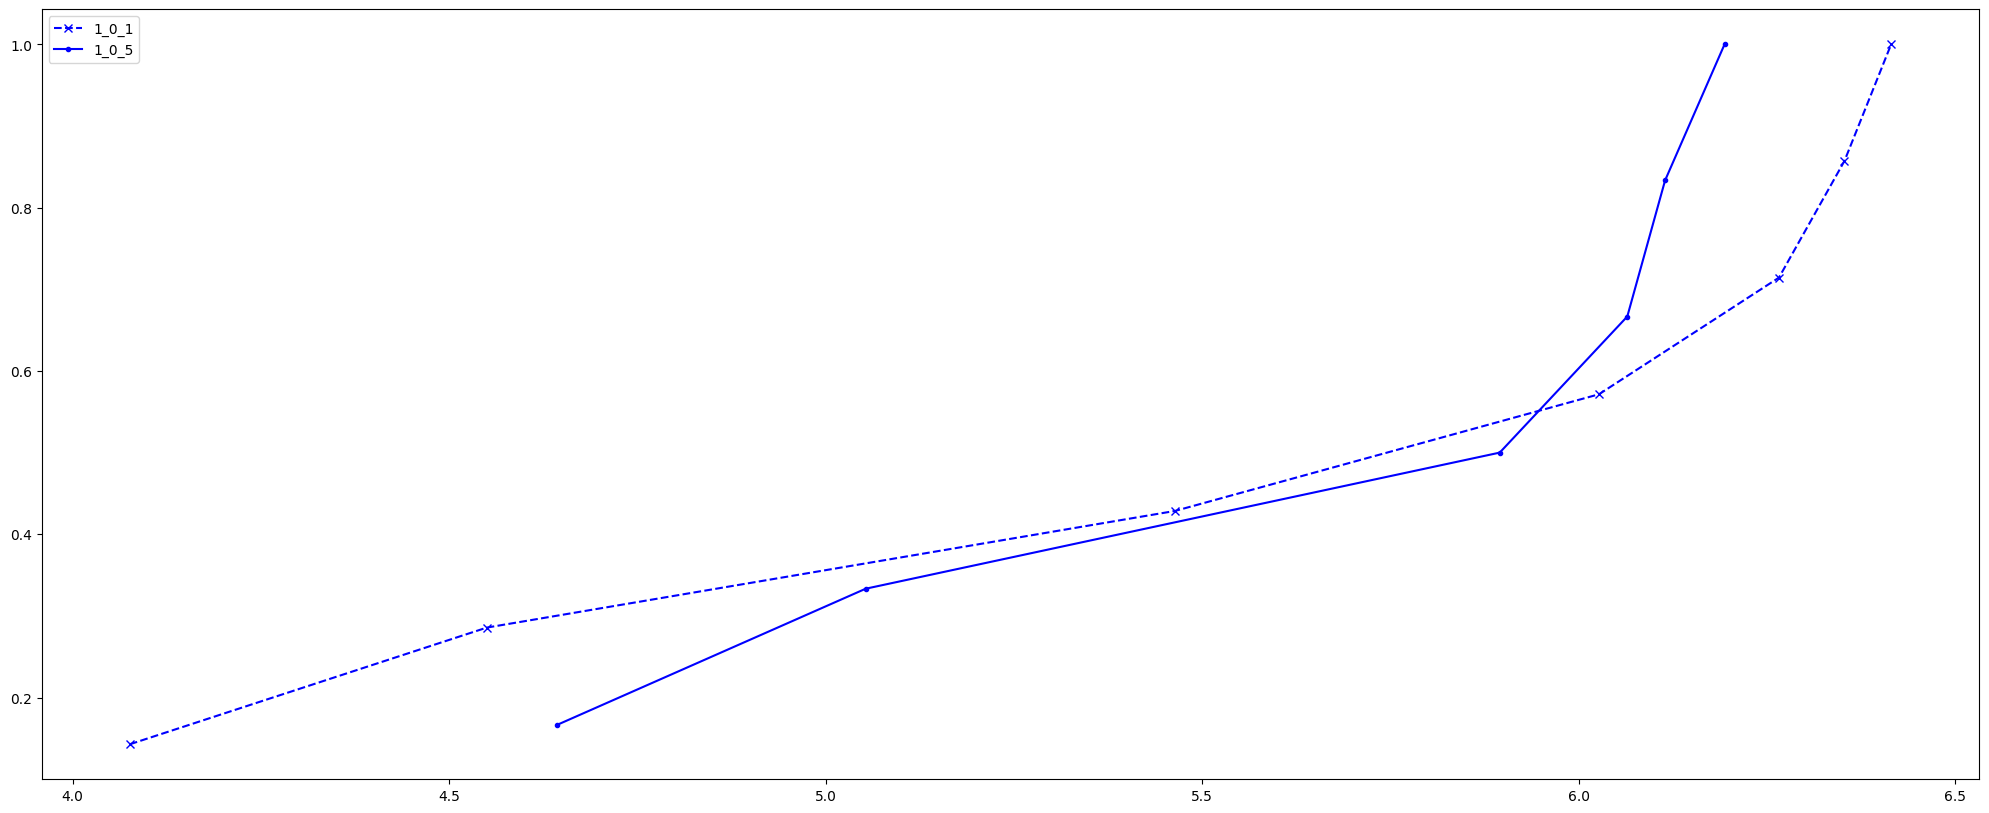

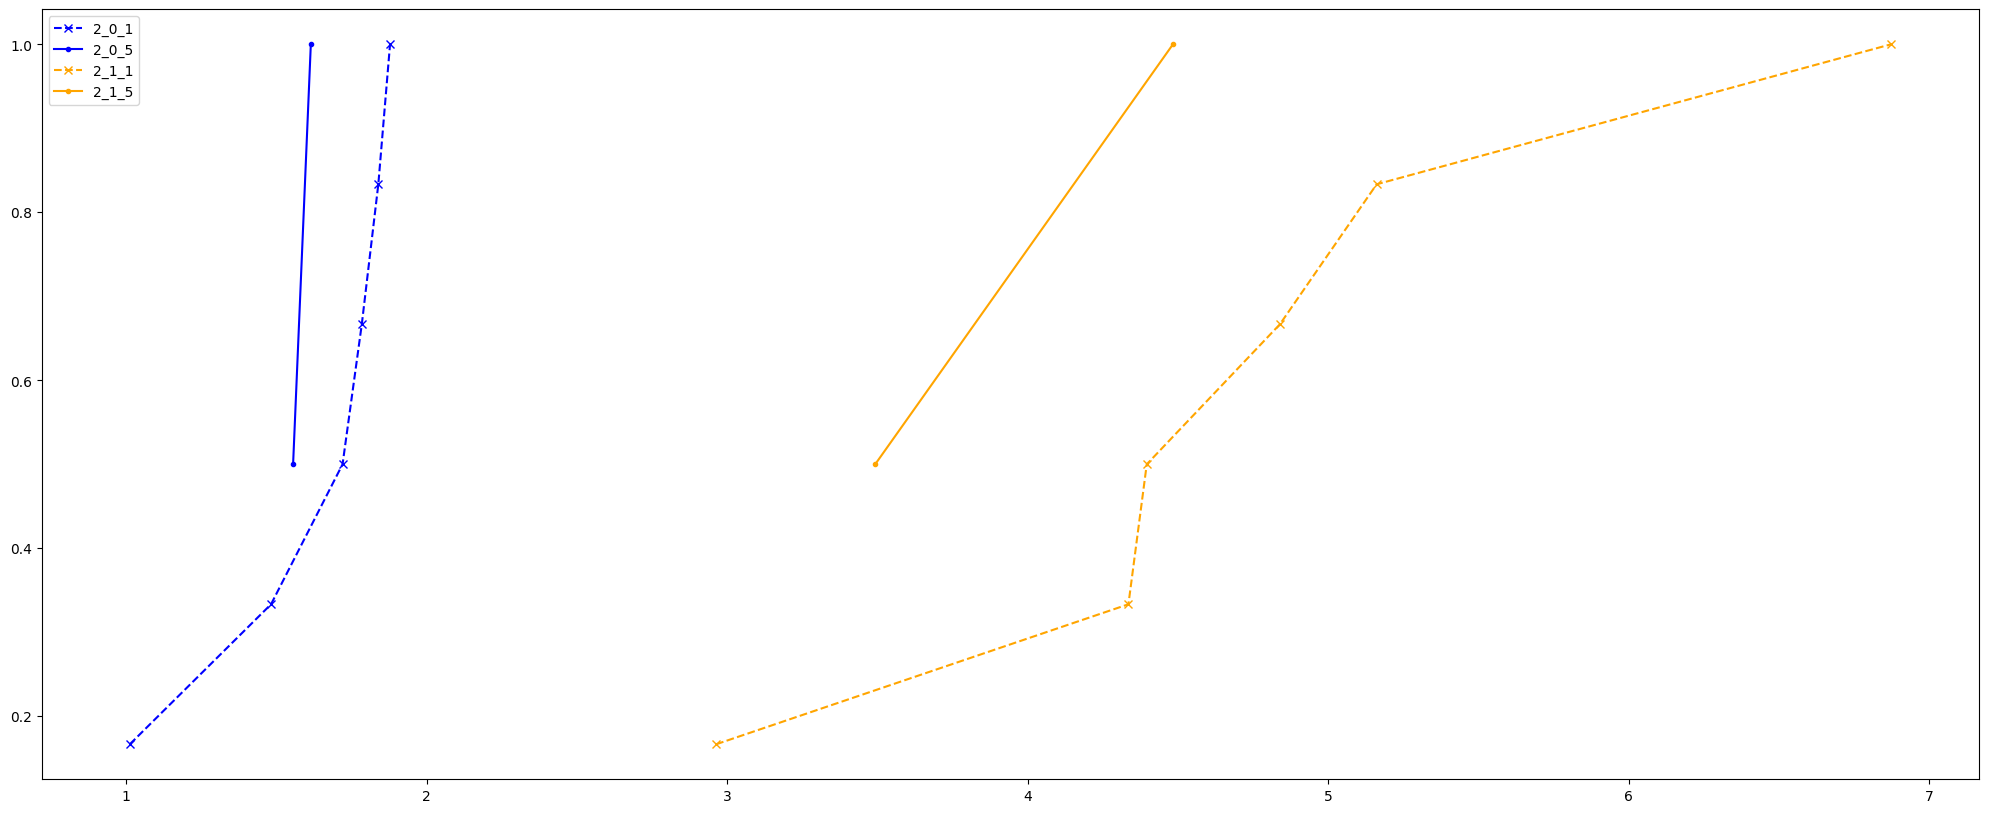

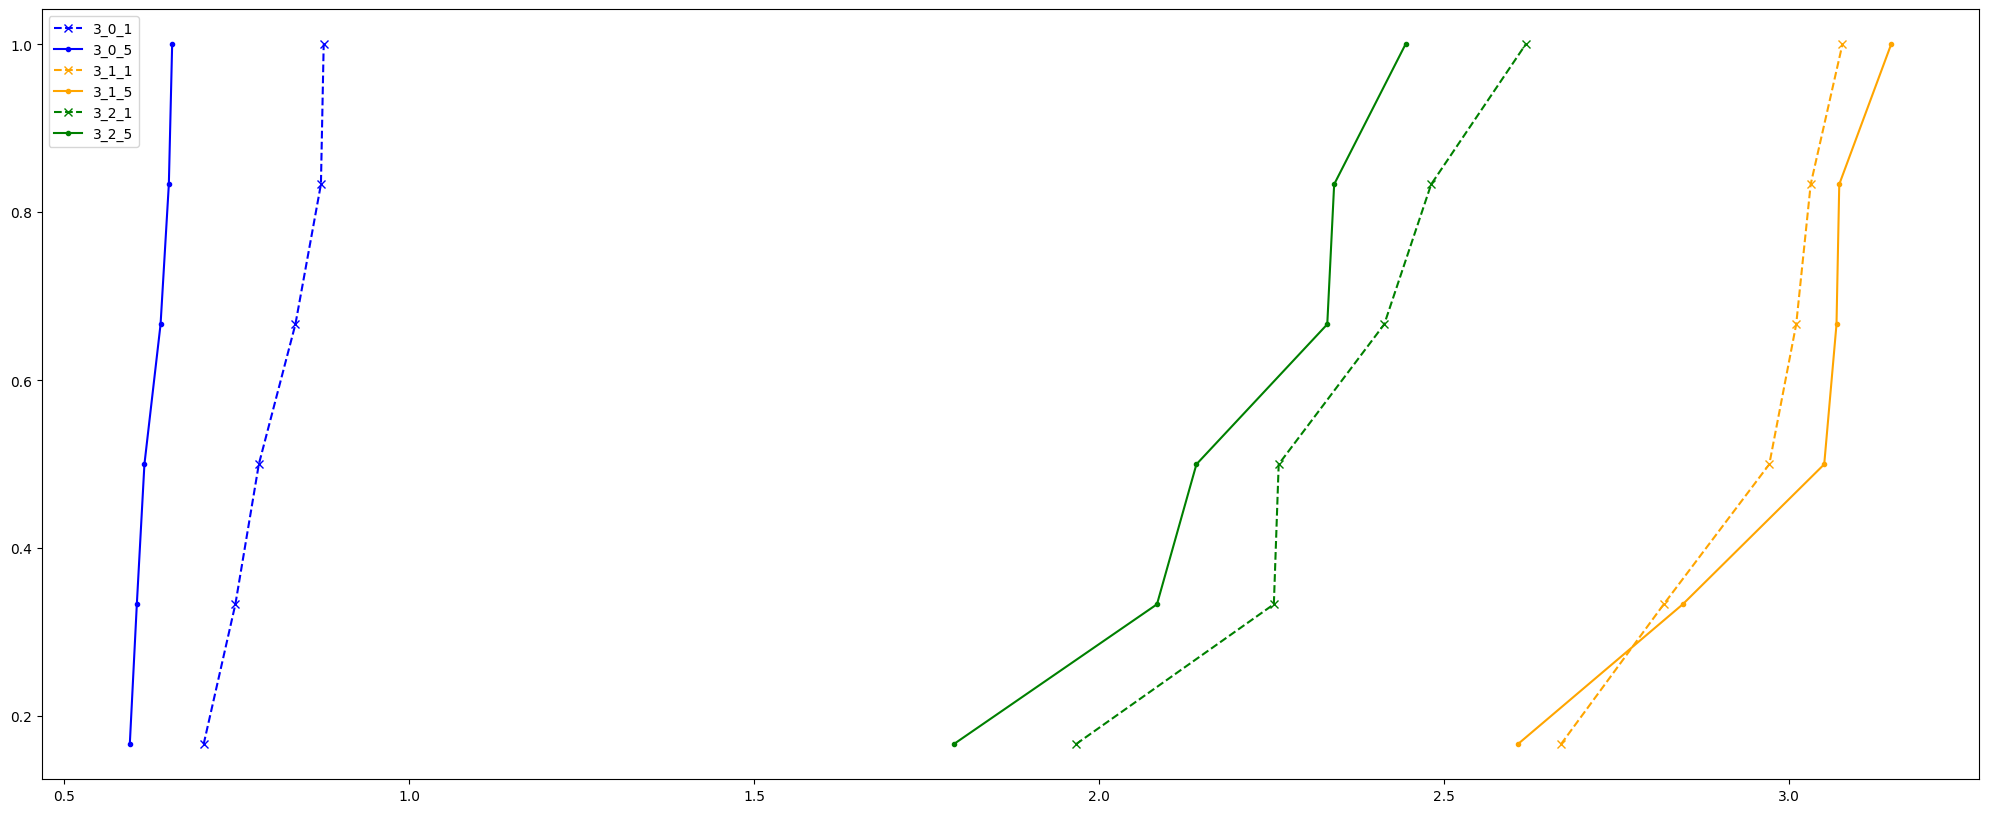

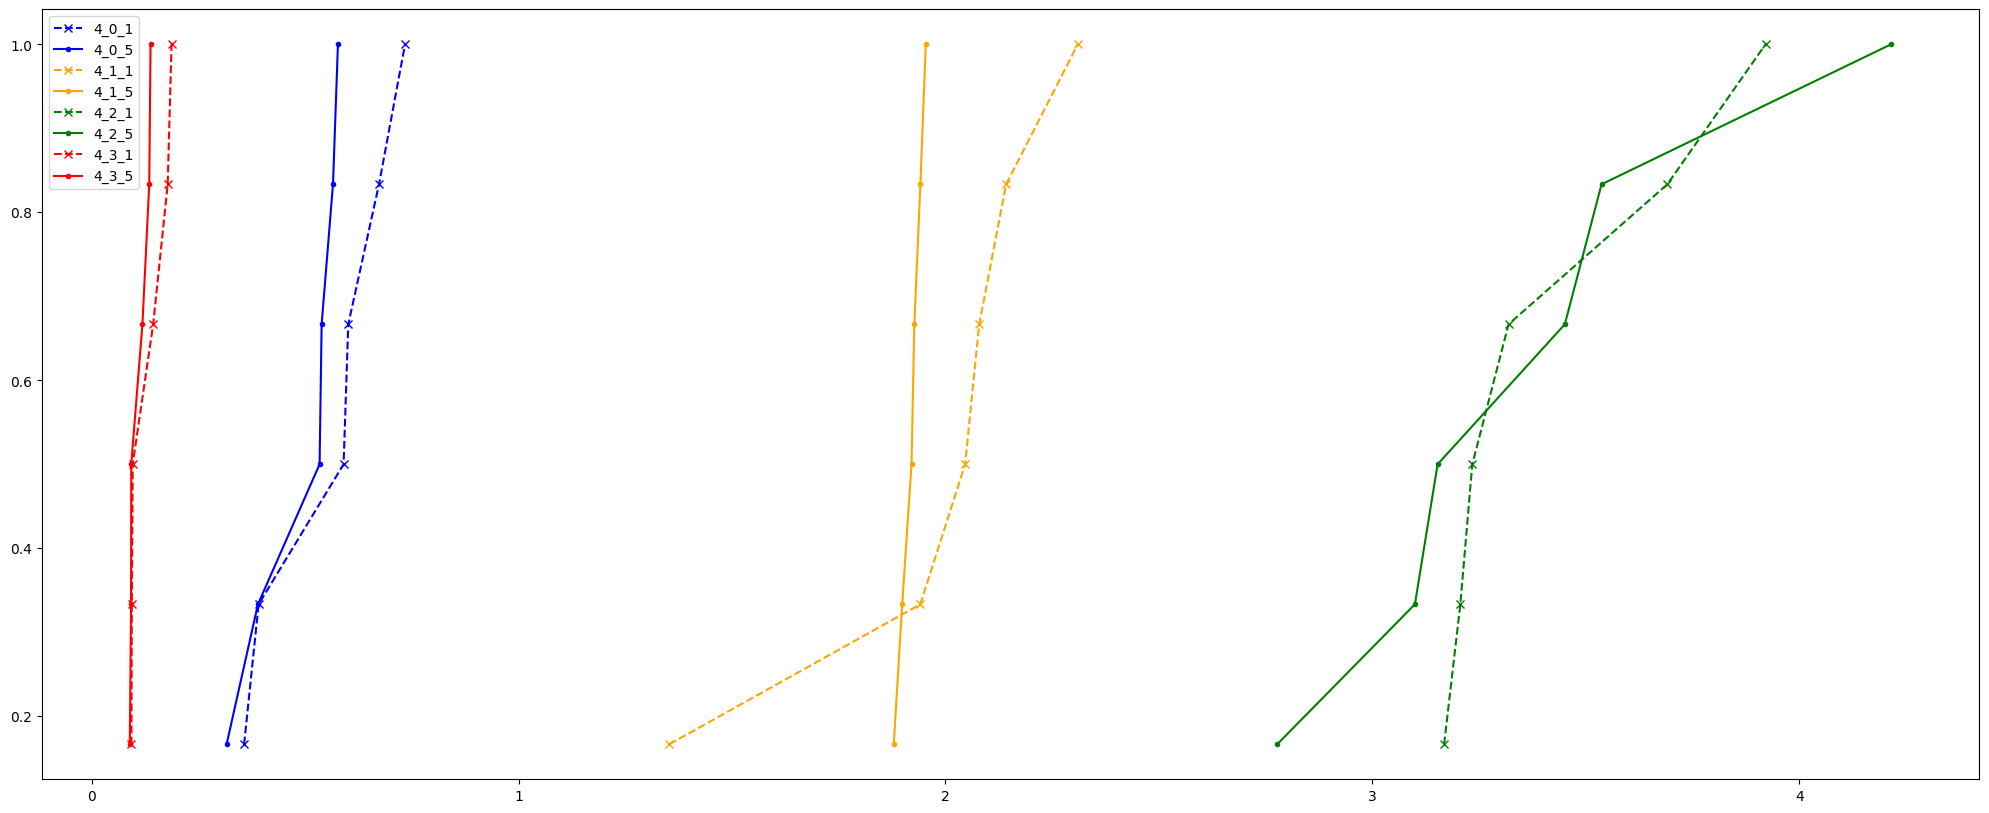

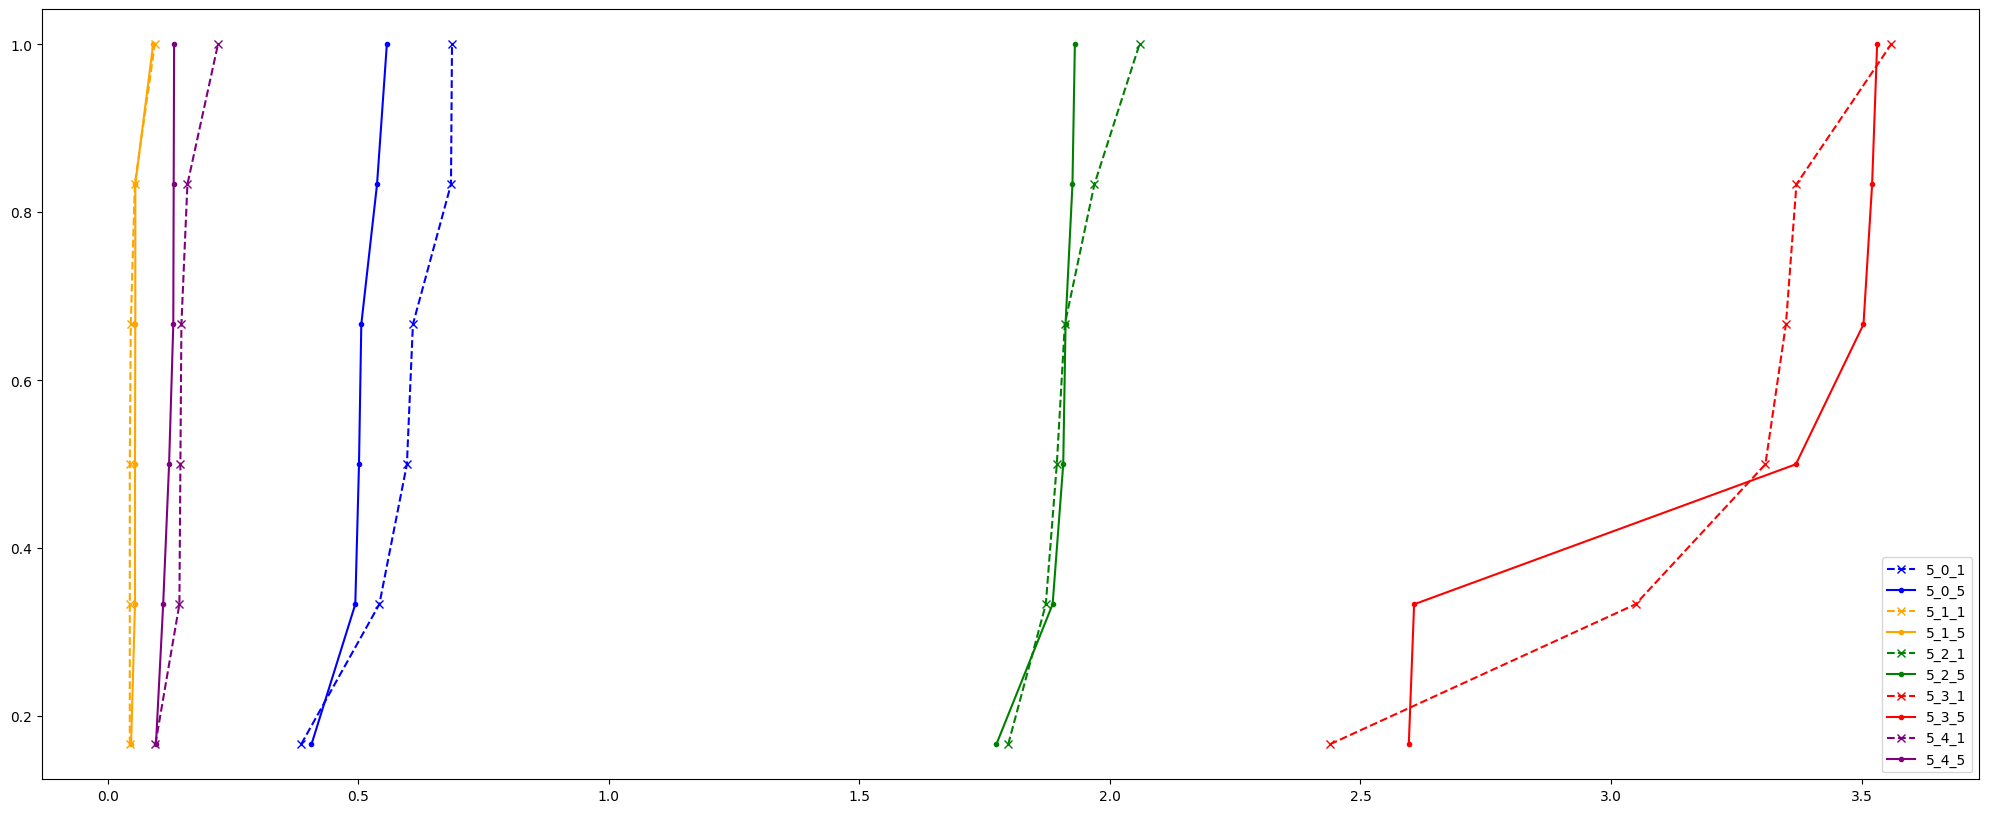

In [264]:
#for bramble-2-1 specifically only
pdu_tag = "bramble-2-1"
worlds=[1,2,3,4,5]
bnums=[1,5]
con=1
warmups = {con:{}}
nets = {con:{}}
totals = {con:{}}
devs=[i for i in range(1,43)]
batch_warmups = {}
repeats=[i for i in range(1,11)]
for repeat in repeats:
    for world in worlds:
        if world not in batch_warmups:
            batch_warmups[world]={}
        
        if world not in warmups[con]:
            warmups[con][world] = {}
            nets[con][world] = {}
            totals[con][world] = {}
            
        for bnum in bnums:
            if bnum not in batch_warmups[world]:
                batch_warmups[world][bnum] = {}
            
            for dev in devs:
                path=f"/Users/animeshnd/model_splitting/logs/roofline/{pdu_tag}/resnet18_children/{repeat}/con_{con*world}_{con}_{world}/{world}_size/1_{bnum}/speed_chronos{pdu_tag}-{dev}.log"
                if Path.is_file(Path(path)):
                    r=stat_reader(path)
                    if "failed" in r:
                        print(path)
                        continue
                    
                    rank = r["rank"]
                    if rank not in batch_warmups[world][bnum]:
                        batch_warmups[world][bnum][rank]={}
                    warmup = r["warmup"]
                    comp_times = r["comp_times"]
                    net_times = r["net_times"]

                    agg_warmup=0
                    tally_warmup=[]
                    for i in range(len(comp_times)):
                        agg_warmup=max([ j[1]/1000 for j in warmup[i]])
                        tally_warmup.append(agg_warmup)
                        if i not in batch_warmups[world][bnum][rank]:
                            batch_warmups[world][bnum][rank][i]=[]
                    batch_warmups[world][bnum][rank][i].append(sum(tally_warmup)/bnum)
                    # batch_warmups[world][bnum][rank][i].append((sum(tally_warmup)/bnum+max(net_times+[0])))



                        # for j in range(len(warmup[i])):
                        #     print( len(warmup[i][j]), len(warmup[i]), bnum, len(warmup))
                    # total_times = r["comp_times"]
                    # print(len(warmup), len(total_times))
                    if bnum==1 and r["world"]==world and len(r["comp_times"])==1:
                        warmup = r["warmup"]
                        net=r["net_times"]
                        comp_times = r["comp_times"]
                        total_times = r["total_times"]
                        agg_warmup = 0
                        rank=r["rank"]
                        for i in range(len(comp_times)):
                            # print(len(warmup[i]), len(warmup[i][0]))
                            agg_warmup = max([ float(np.median(j[1:])/1000) for j in warmup[i]]) #skip first because that's warmup run
                        if rank not in warmups[con][world]:
                            warmups[con][world][rank]=[]
                            nets[con][world][rank]=[]
                            totals[con][world][rank]=[]
                        warmups[con][world][rank].append(agg_warmup)
                        nets[con][world][rank].append(sum(net))
                        totals[con][world][rank].append(sum(total_times)/len(warmup[0][0]))
                        
                        # if rank-1 in totals[con][world]:
                        #     nets[con][world][rank][-1] = nets[con][world][rank][-1] - totals[con][world][rank-1][-1]
                    
                    
                    # print(r)
                # raise Exception("end it")
# print(warmups)
colors=["blue", "orange", "green", "red", "purple"]

for world in [1,2,3,4,5]:
    fig, axs = plt.subplots(figsize=(25,10))
    for rank in range(world):
        accum={}
        for bnum in bnums:
            if bnum not in accum:
                accum[bnum] = []
            # accum={}
            # t_accum = [0]*len(batch_warmups[world][bnum][rank][0])
            for n in range(bnum):
                # print(world, bnum, rank, n)
                batch_warmups[world][bnum][rank][n] = [ i for i in batch_warmups[world][bnum][rank][n] ]#if i < min(batch_warmups[world][bnum][rank][n])*3] 
                # t_accum=[t_accum[i]+batch_warmups[world][bnum][rank][n][i] for i in range(len(t_accum)) if i < len(batch_warmups[world][bnum][rank][n])]
                accum[bnum].extend(batch_warmups[world][bnum][rank][n])
                # if n not in accum:
                #     accum[n] = []
            # accum[bnum].extend([t/bnum for t in t_accum])
                # x,y = cdf_gen(batch_warmups[world][bnum][rank][n])
                # axs.plot(x,y, label=f"{world}_{rank}_{n}", color=colors[rank], linestyle=("--" if bnum==1 else "-"), alpha=(1 if bnum==1 or bnum==5 else 0.2) )

        # if rank==world-1:
        for n in accum:
            x,y=cdf_gen(accum[n])
            axs.plot(x,y, label=f"{world}_{rank}_{n}", color=colors[rank], marker="x" if n==1 else ".", linestyle=("--" if n==1 else "-"), alpha=(1 if n==1 or n==5 else 0.2))
        
    axs.legend()
    # break


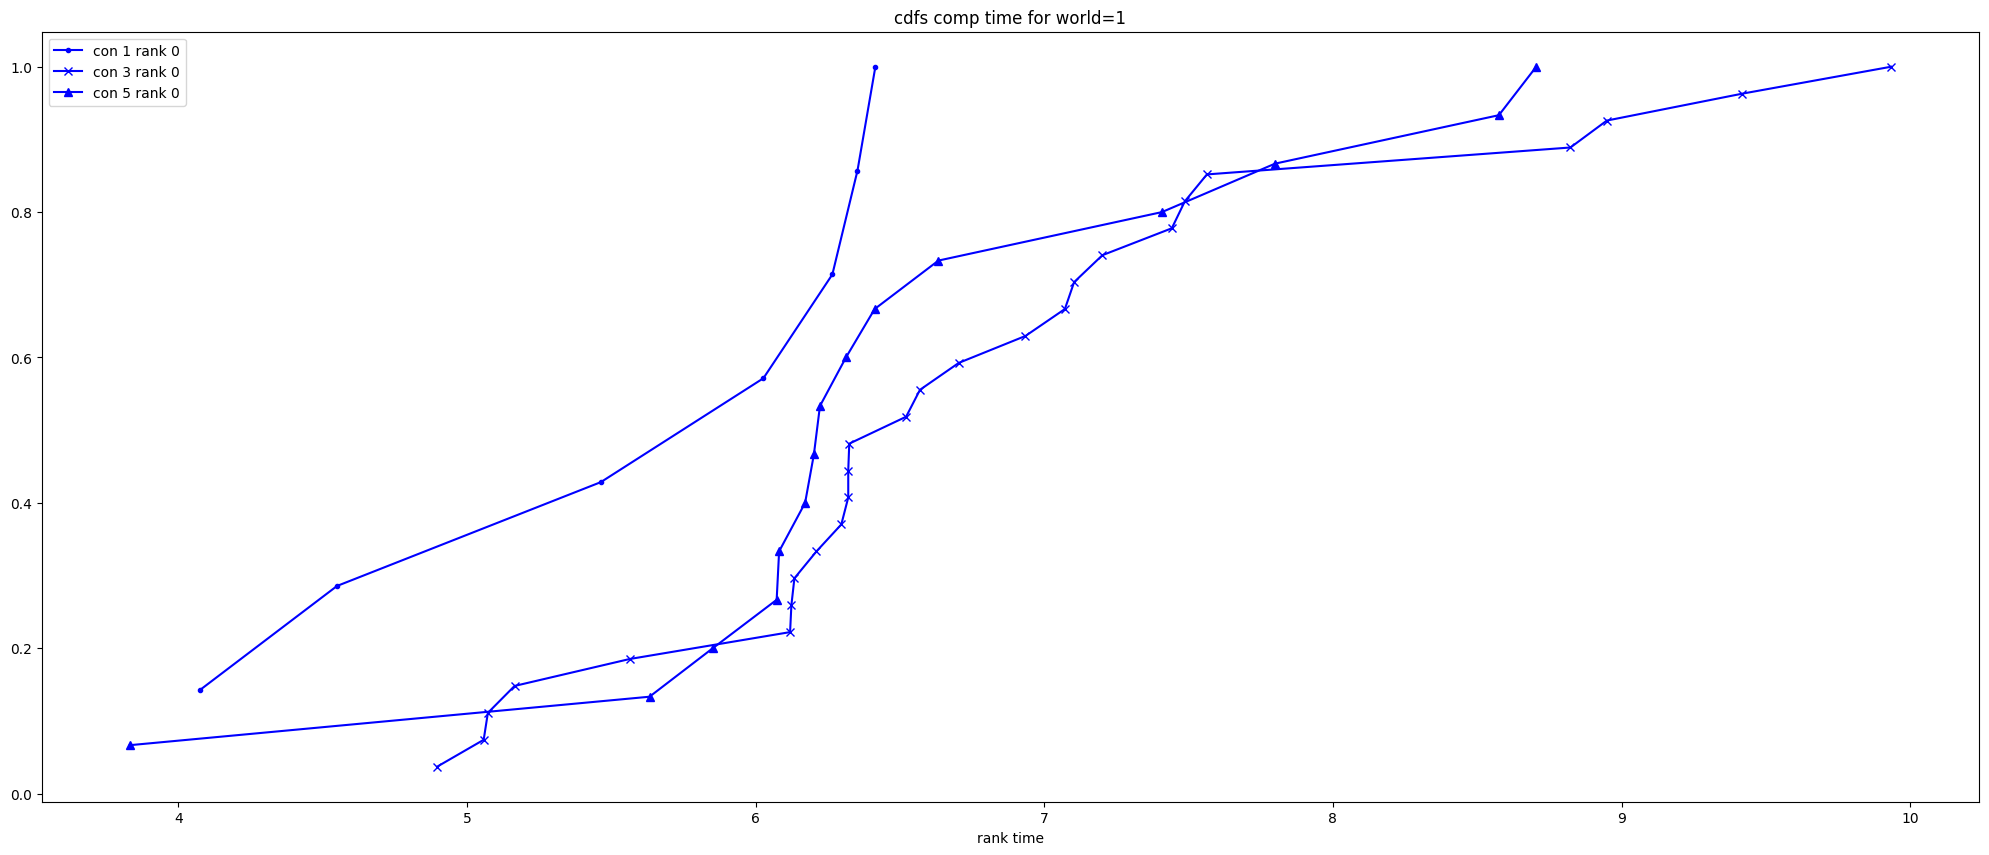

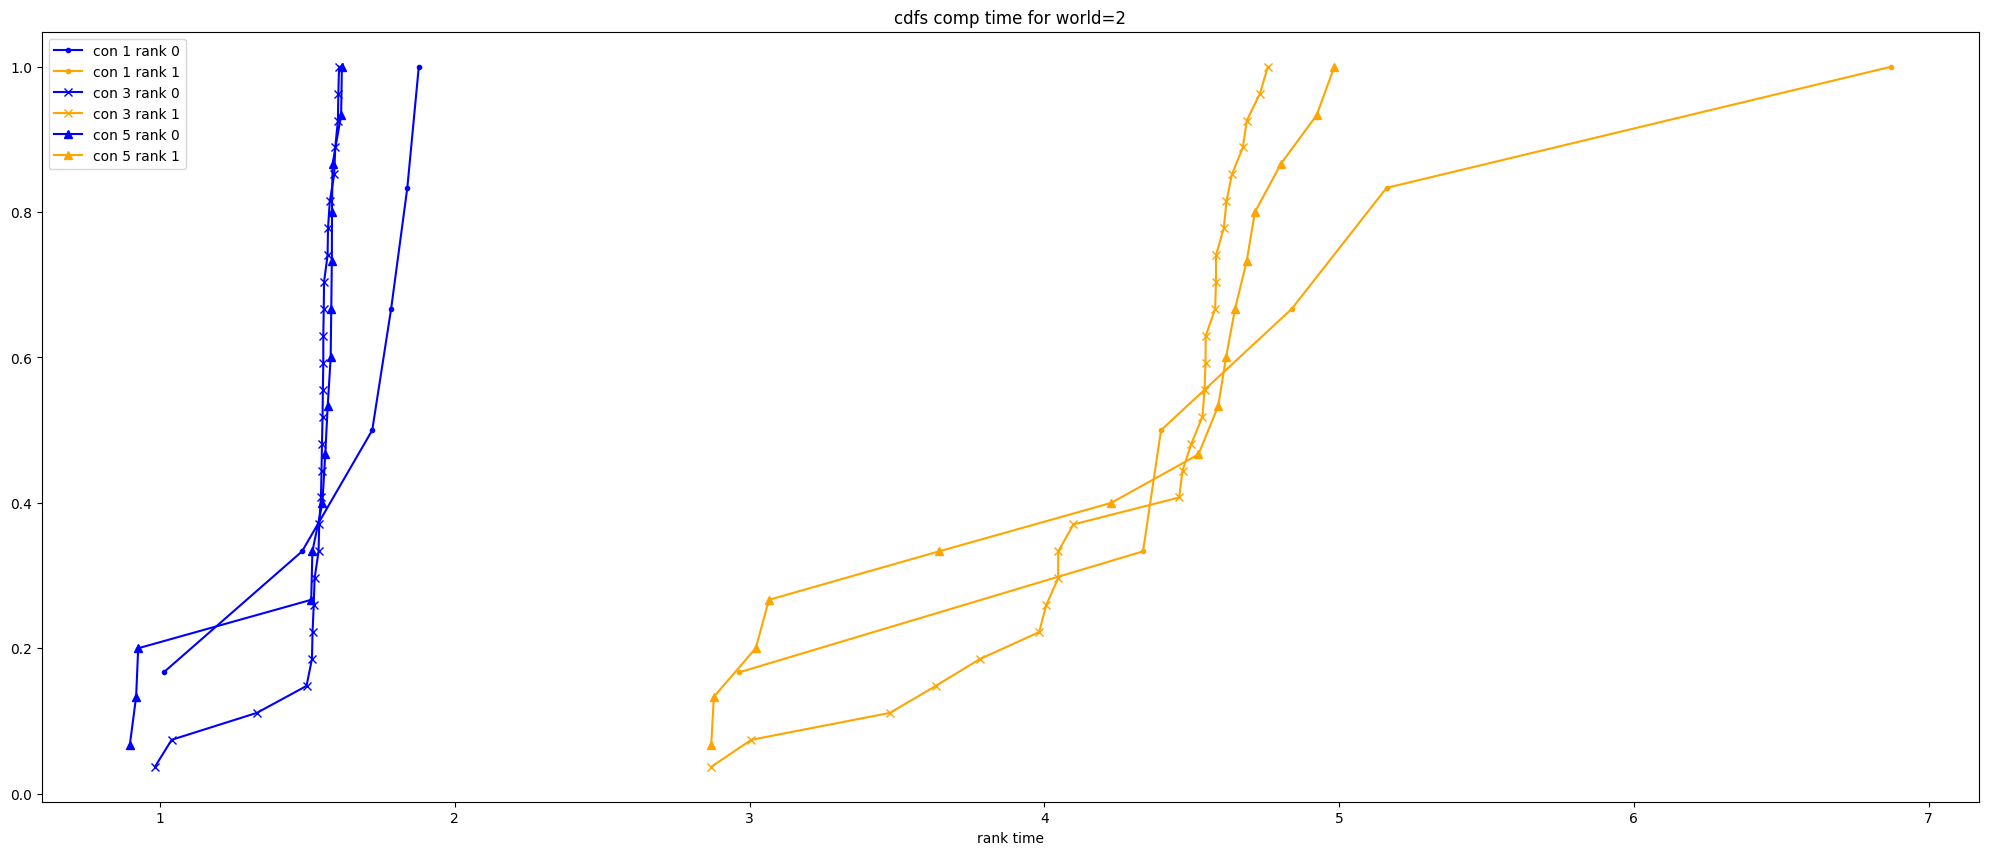

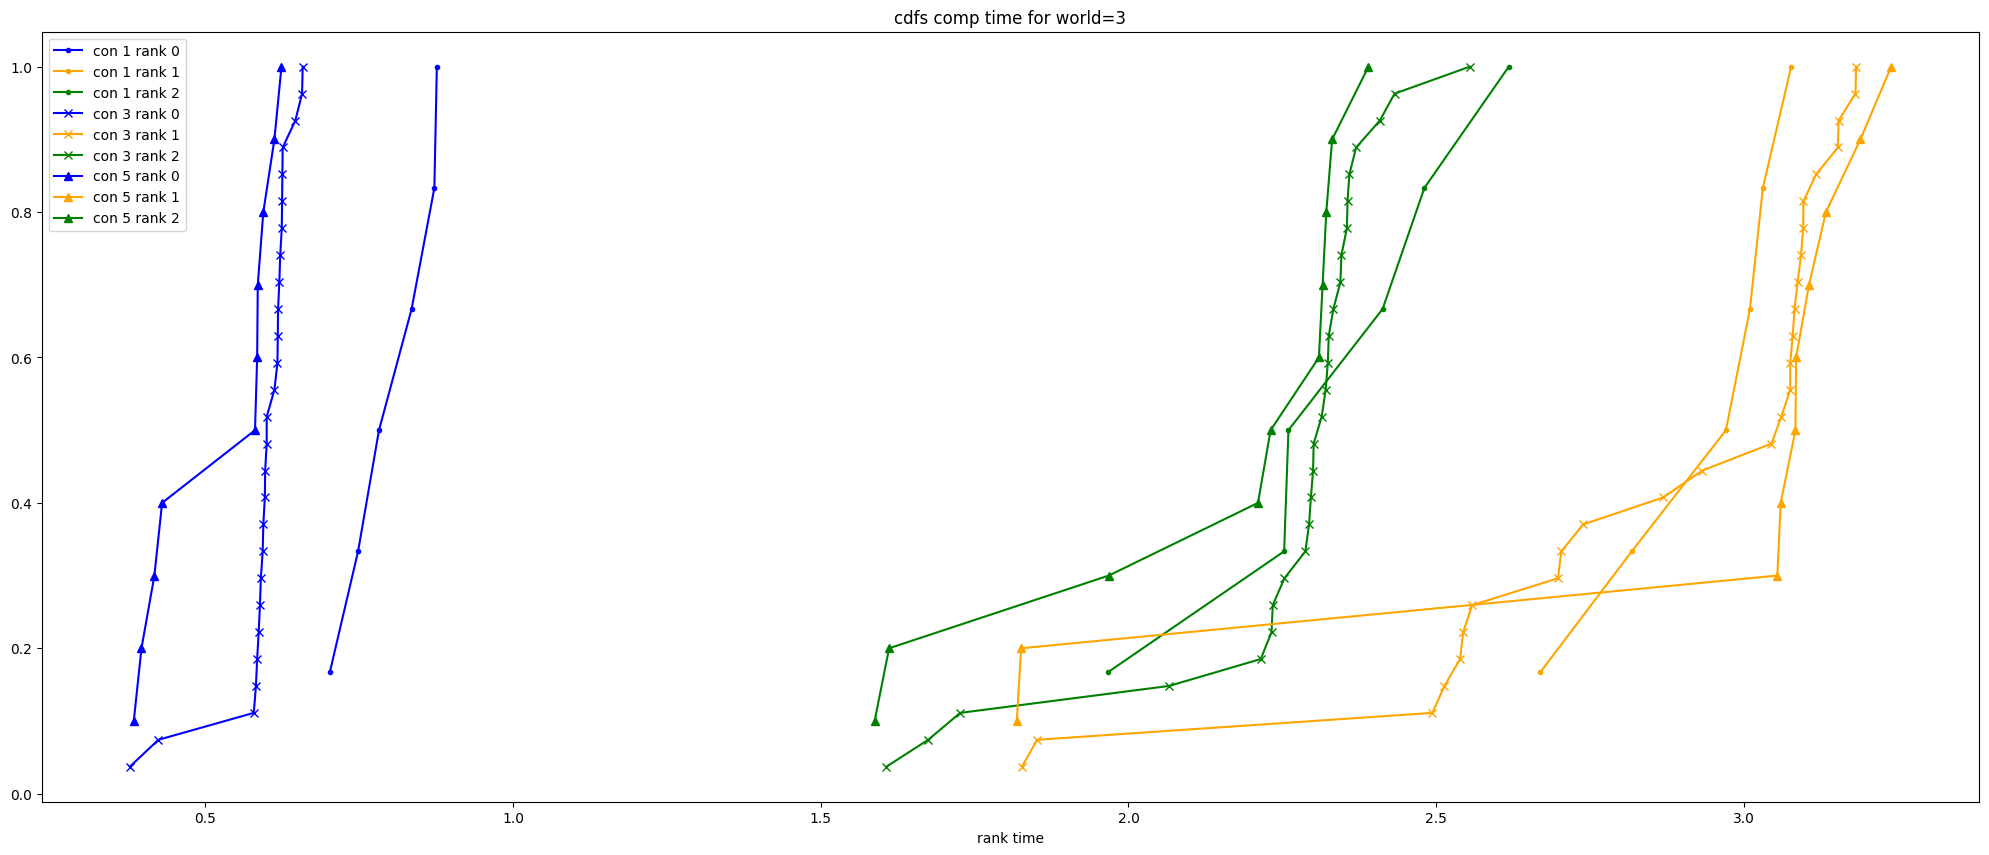

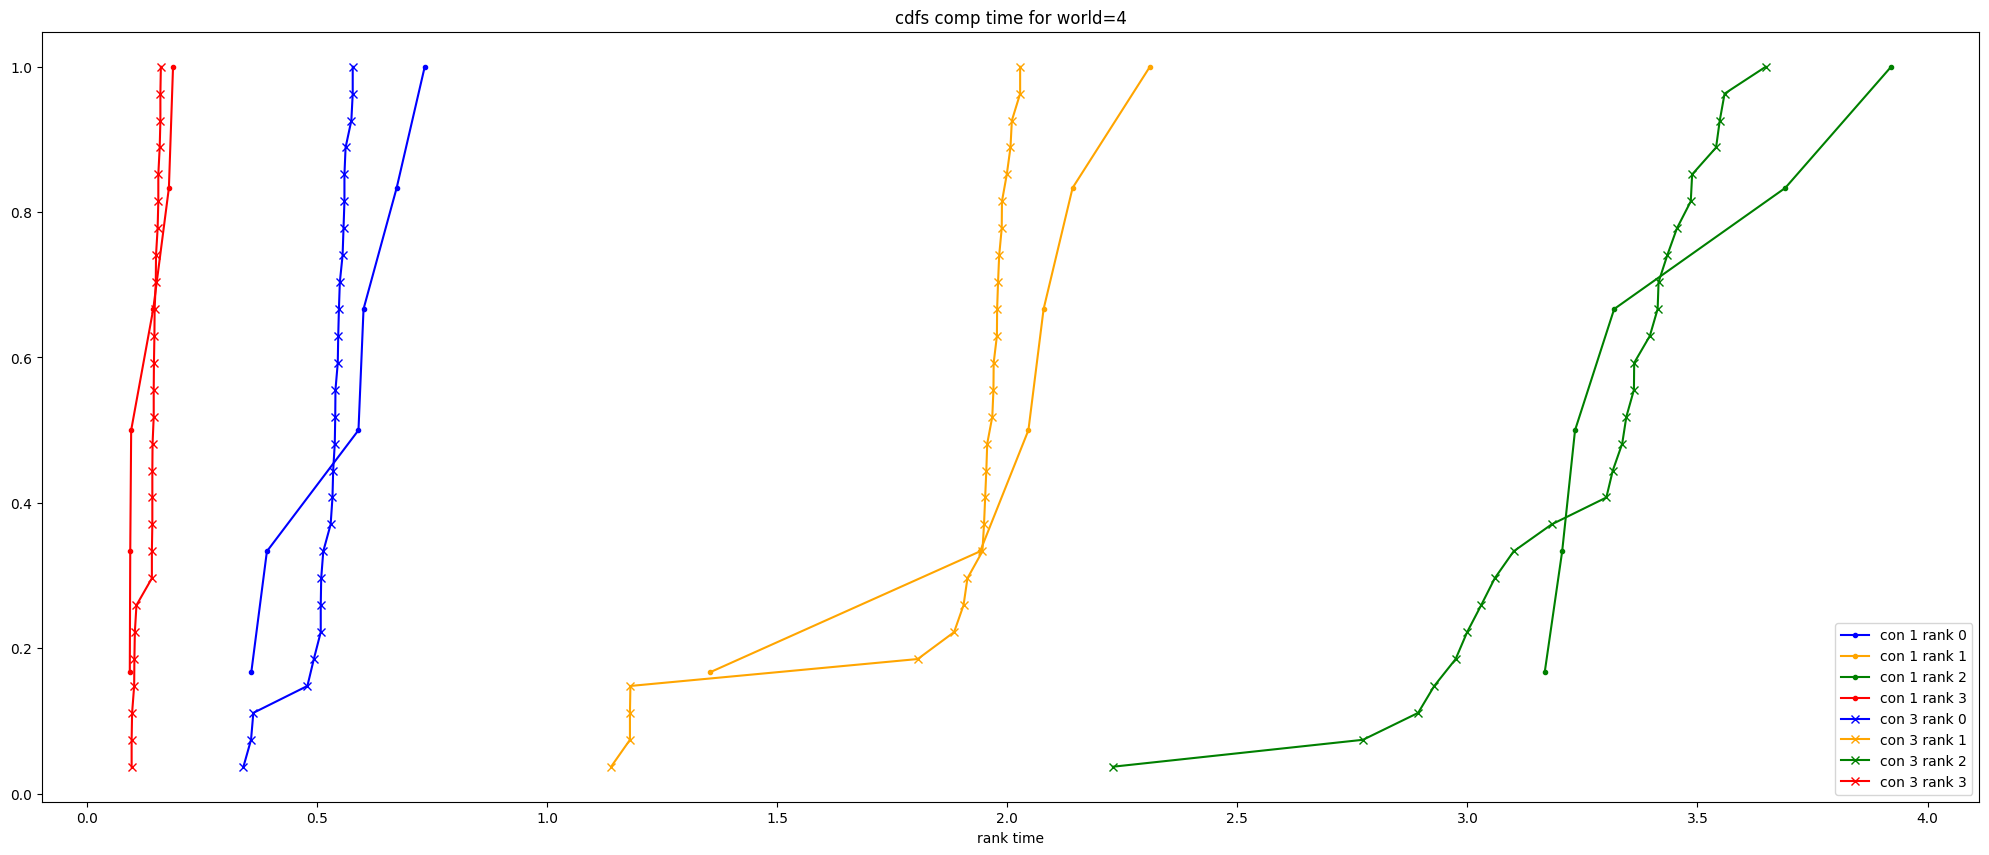

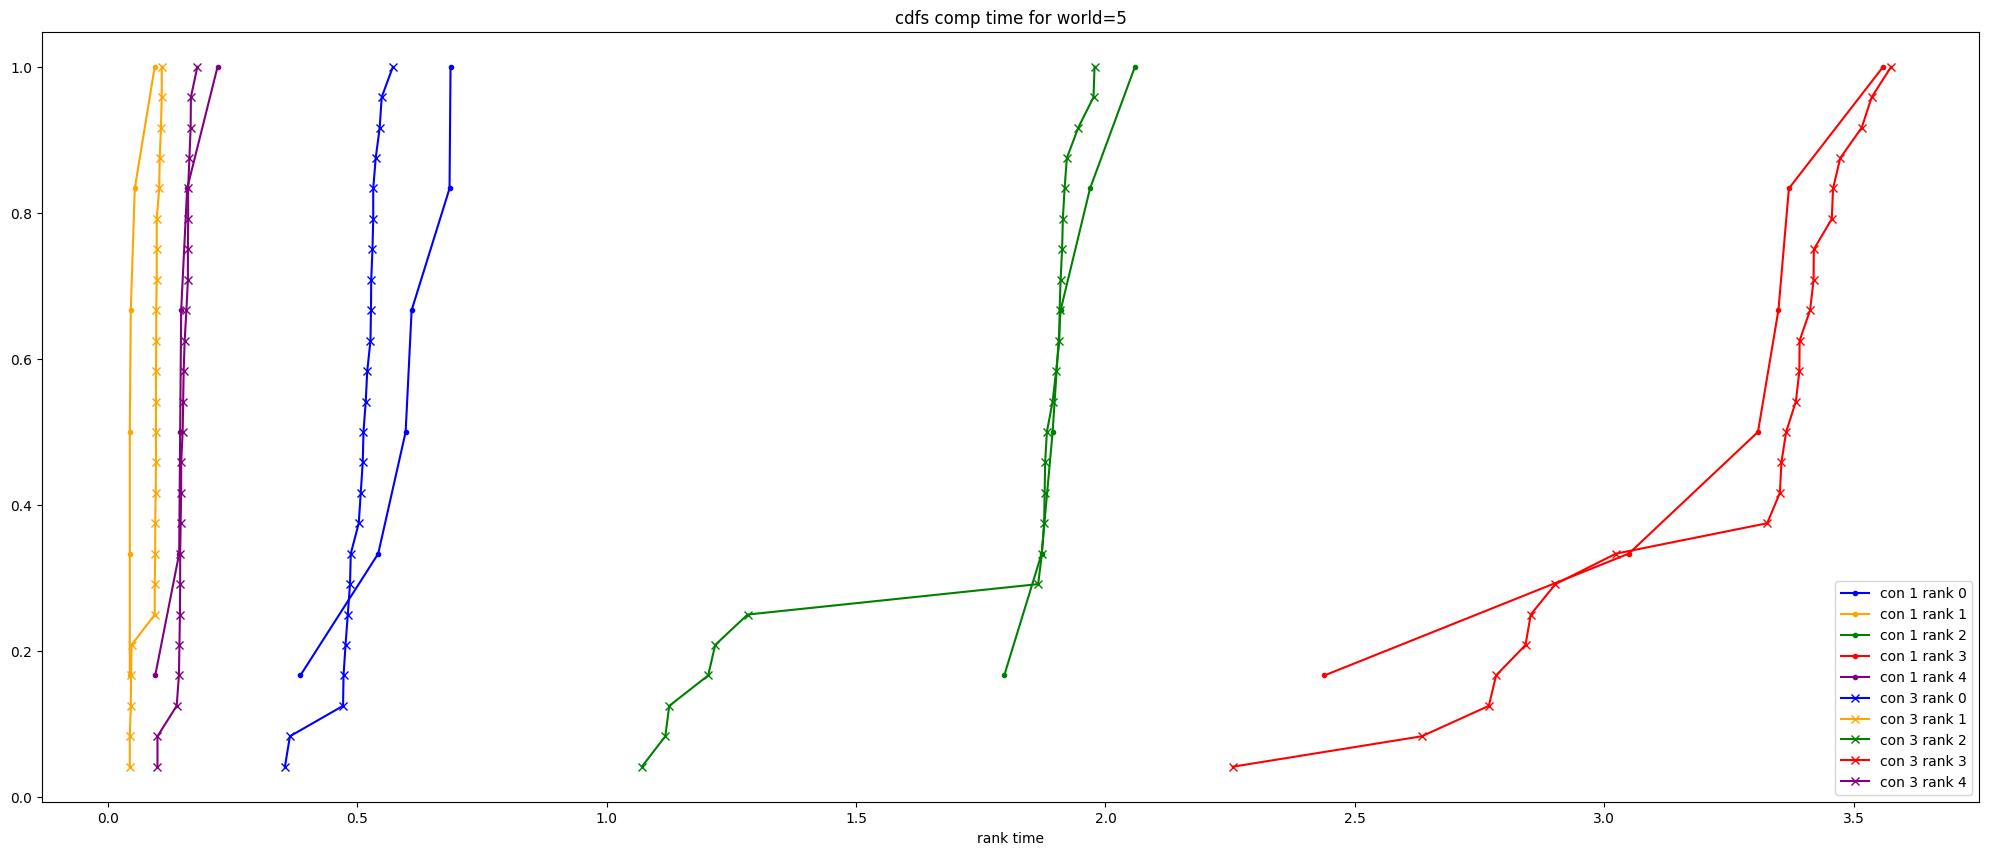

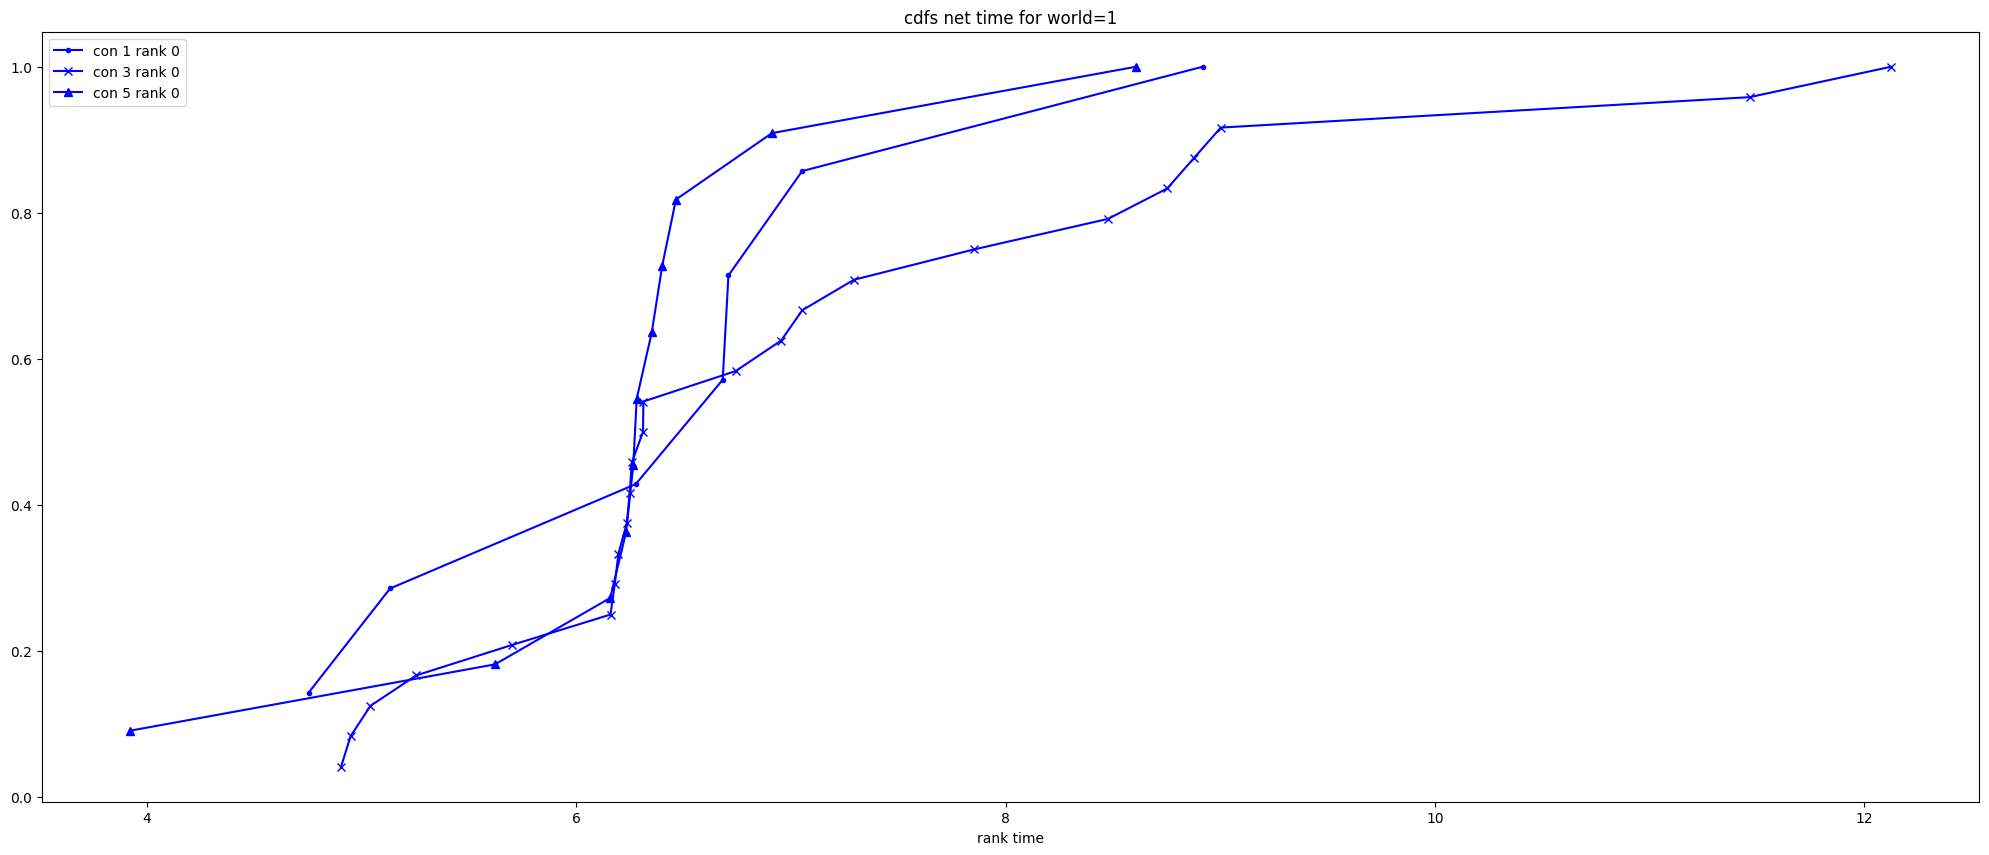

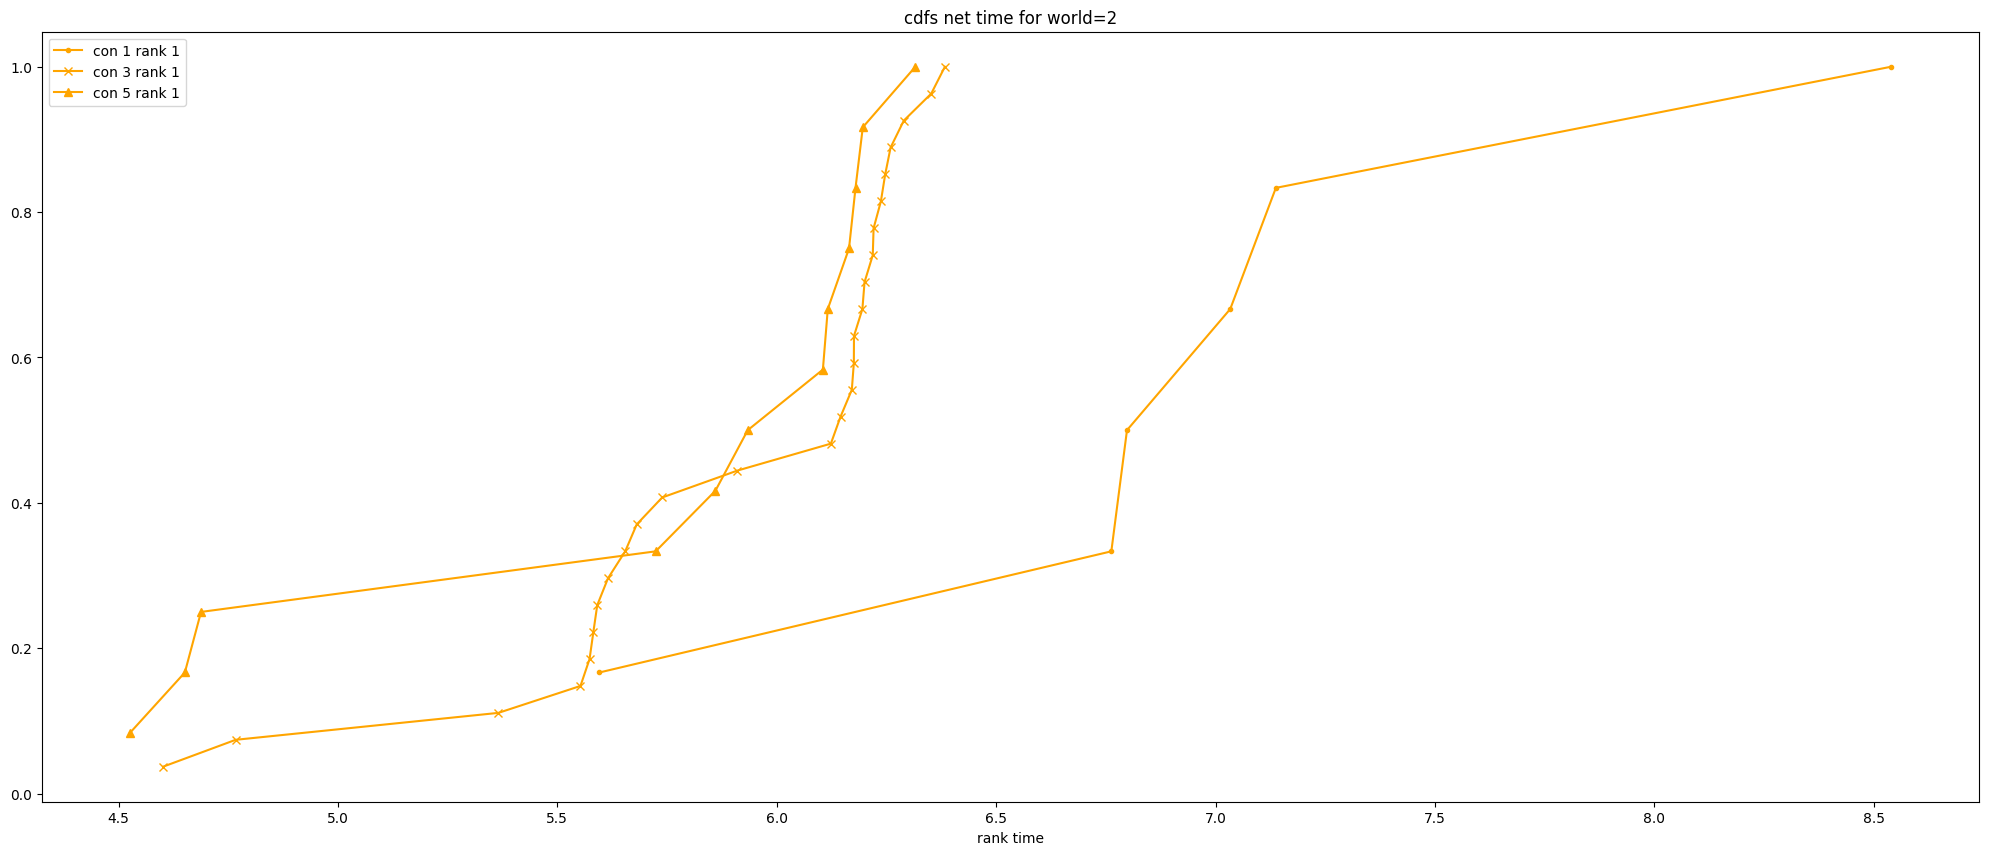

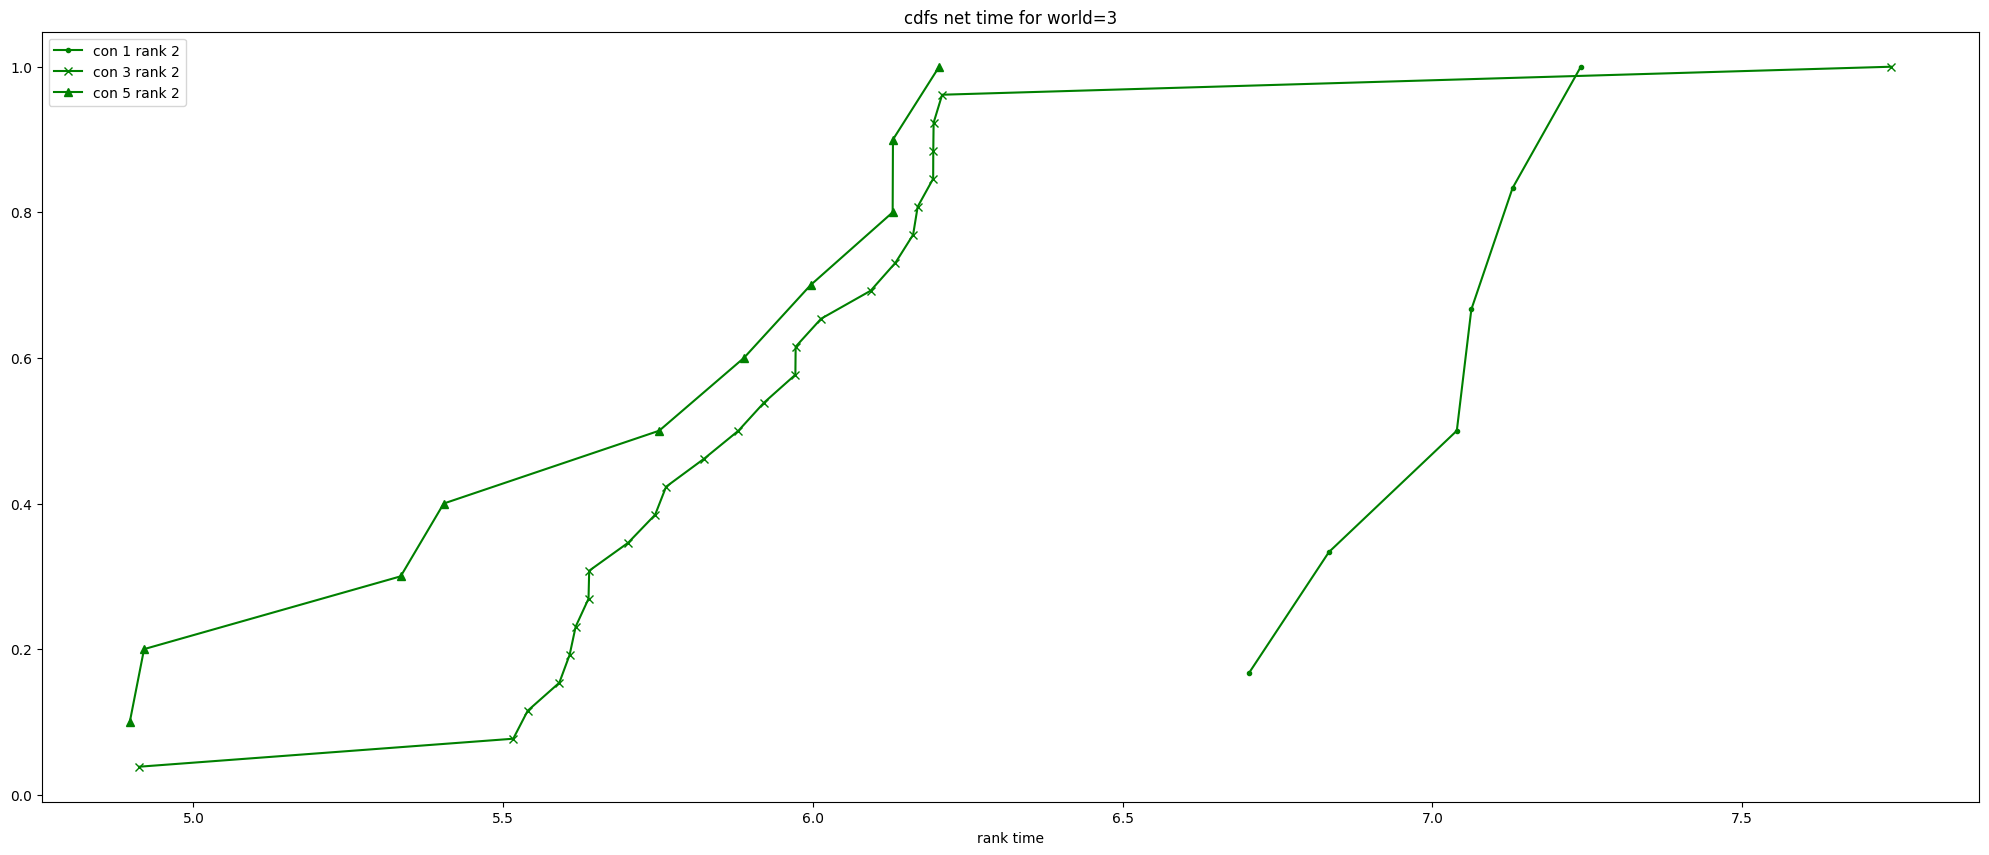

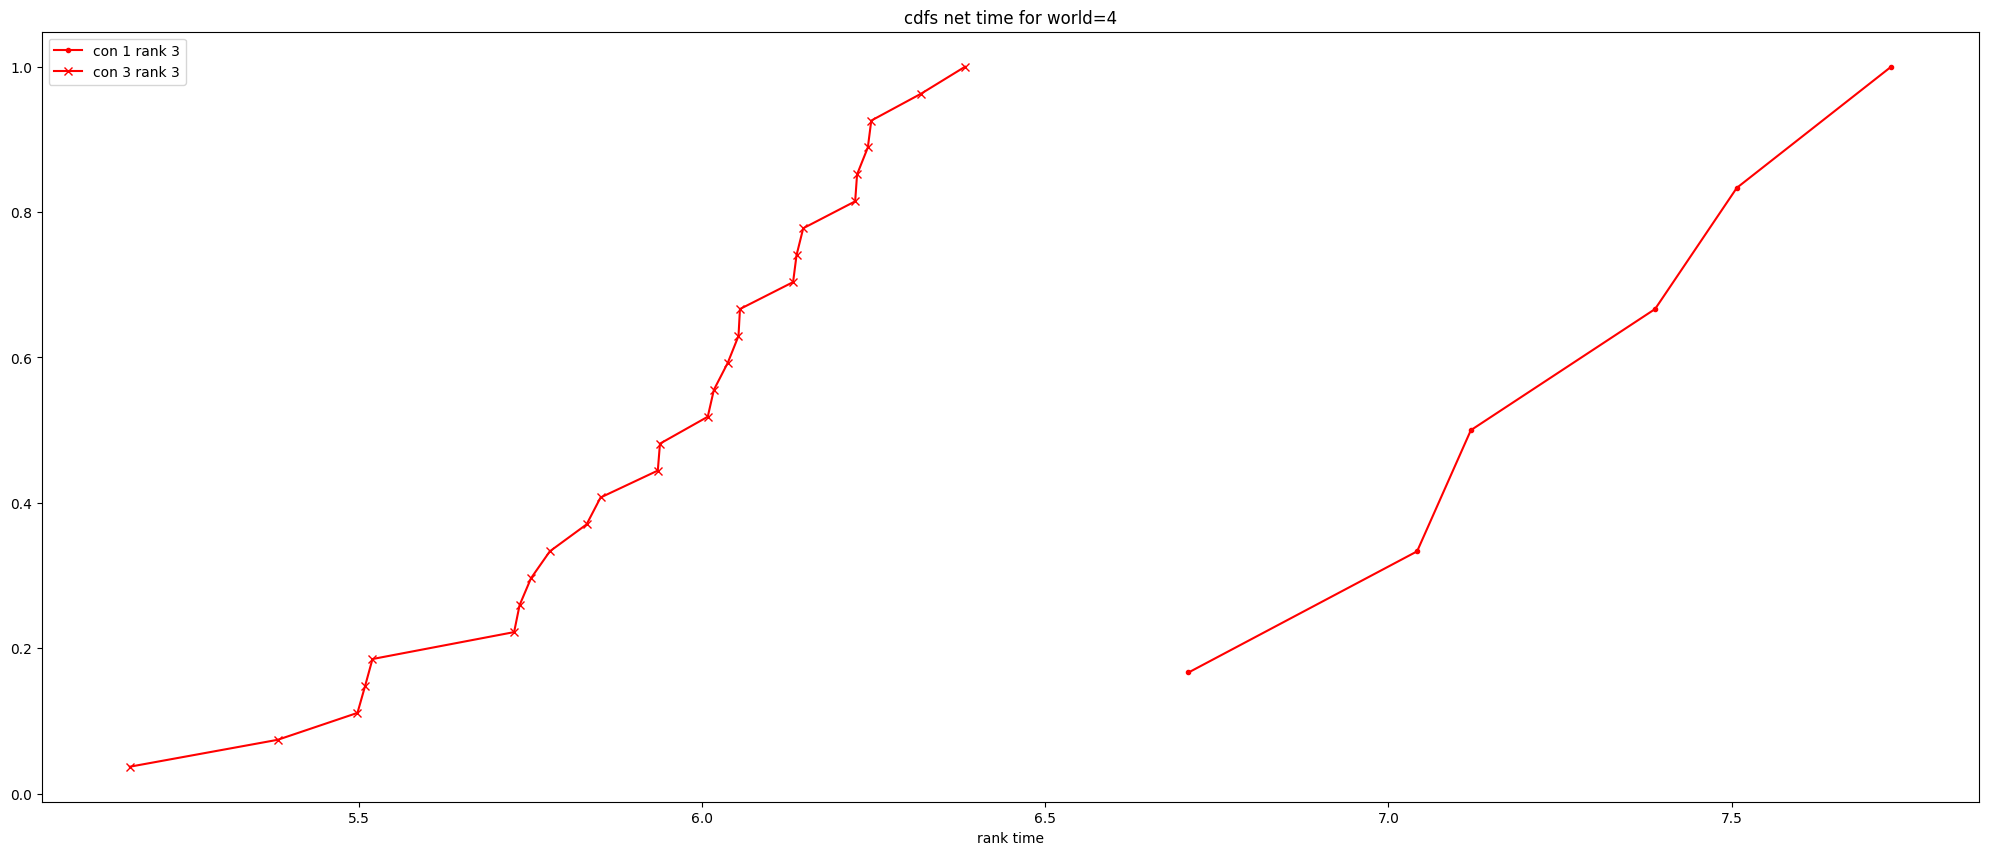

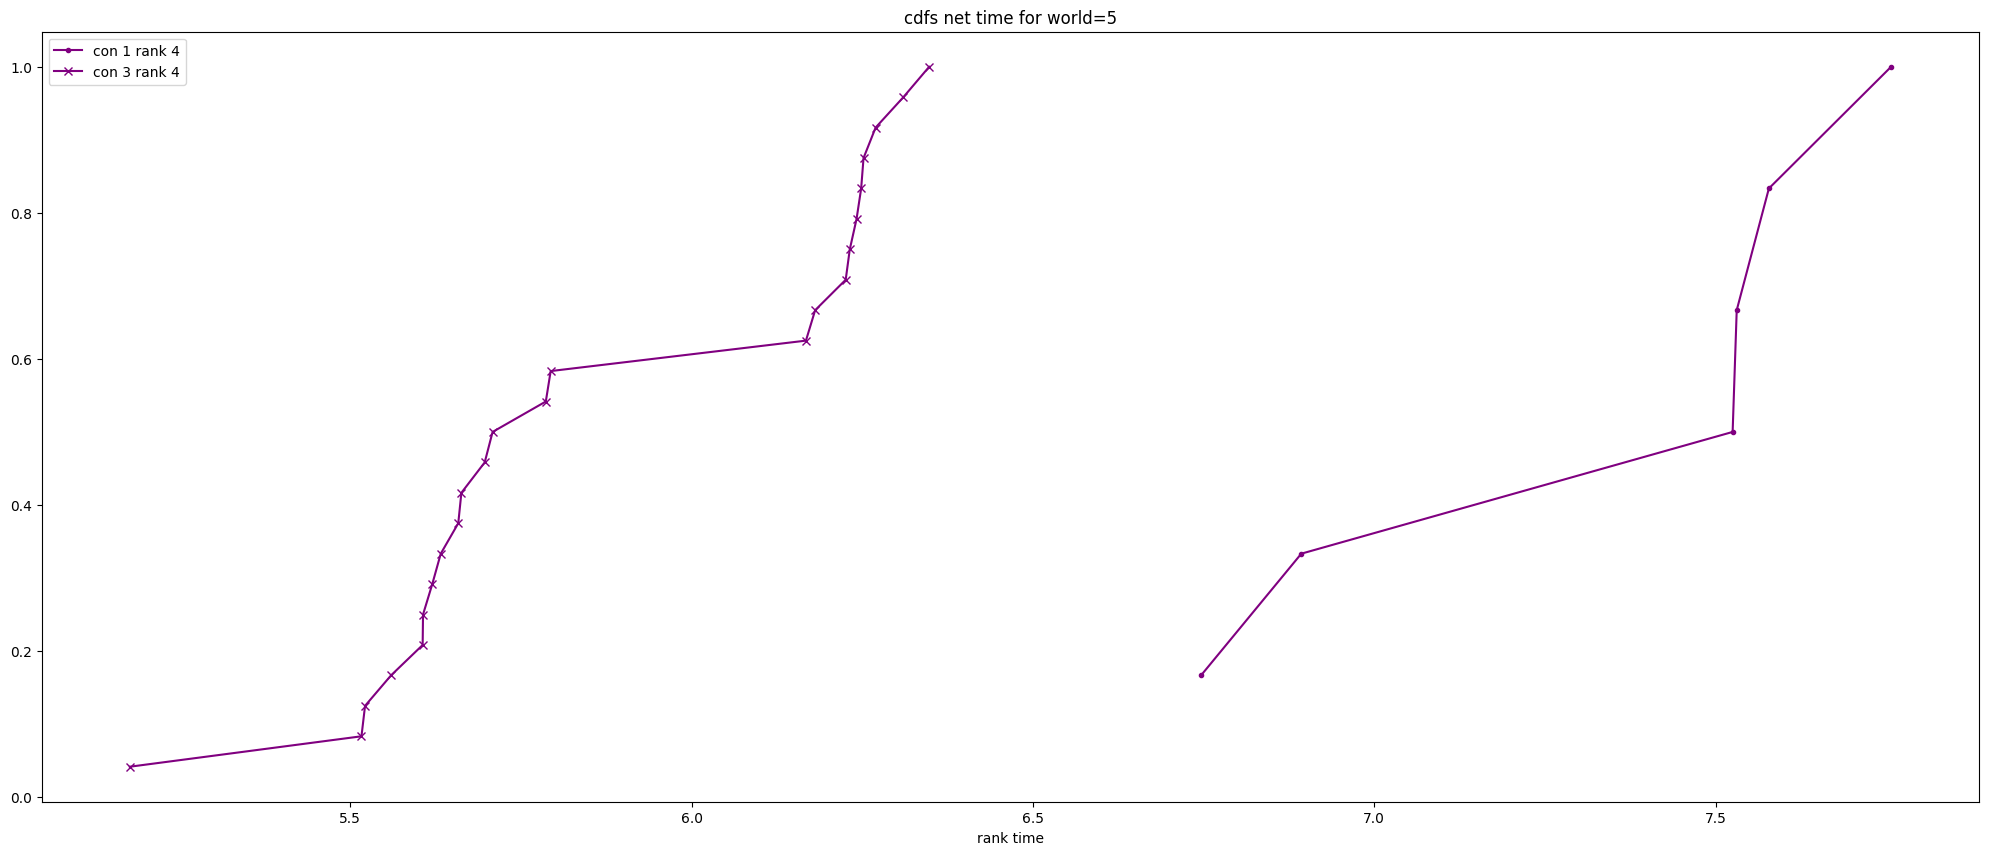

In [218]:
# pdu_tag = "bramble-2-1"
# worlds=[1,2,3,4,5]
# con=1
# # warmups = {con:{}}
# # devs=[i for i in range(1,43)]
# # repeats=[i for i in range(1,11)]
# warmup_collect(con, pdu_tag, warmups, nets, totals, worlds)

pdu_tag = "bramble-4-5"
worlds=[1,2,3,4,5]
con=3
warmup_collect(con, pdu_tag, warmups, nets, totals, worlds)
            
pdu_tag = "bramble-4-1"
worlds=[1,2,3]
con=5
warmup_collect(con, pdu_tag, warmups, nets, totals, worlds)


colors=["blue", "orange", "green", "red", "purple"]
styles={1:".", 3:"x", 5:"^"}
for world in [1,2,3,4,5]:
    fig, axs = plt.subplots(figsize=(25,10))
    axs.set_title(f"cdfs comp time for world={world}")
    axs.set_xlabel("rank time")
    for con in warmups:
        if world in warmups[con]:
            for rank in [0,1,2,3,4]:
                if rank in warmups[con][world] and len(warmups[con][world][rank])>1:
                    x,y = cdf_gen(warmups[con][world][rank])
                    axs.plot(x,y, label=f"con {con} rank {rank}", color=colors[rank], marker=styles[con])
            axs.legend()


colors=["blue", "orange", "green", "red", "purple"]
styles={1:".", 3:"x", 5:"^"}
for world in [1,2,3,4,5]:
    fig, axs = plt.subplots(figsize=(25,10))
    axs.set_title(f"cdfs net time for world={world}")
    axs.set_xlabel("rank time")
    for con in totals:
        if world in totals[con]:
            for rank in [0,1,2,3,4]:
                if rank in totals[con][world] and len(totals[con][world][rank])>1 and rank == world-1:
                    # corrected_nets = [ i-totals[con][world][rank-1][i]  for i in range(len(nets[con][world][rank])) if rank-1 in totals[con][world]]
                    # x,y = cdf_gen(nets[con][world][rank])
                    totals[con][world][rank] = [i for i in totals[con][world][rank] if i <= min(totals[con][world][rank])*3]
                    x,y = cdf_gen(totals[con][world][rank])
                    
                    axs.plot(x,y, label=f"con {con} rank {rank}", color=colors[rank], marker=styles[con])
            axs.legend()


# colors=["blue", "orange", "green", "red", "purple"]
# styles={1:".", 3:"x", 5:"^"}
# for world in [1,2,3,4,5]:
#     fig, axs = plt.subplots(figsize=(25,10))
#     axs.set_title(f"cdfs for world={world}")
#     axs.set_xlabel("rank time")
#     for con in nets:
#         if world in nets[con]:
#             for rank in [0,1,2,3,4]:
#                 if rank in nets[con][world] and len(nets[con][world][rank])>1:
#                     x,y = cdf_gen(nets[con][world][rank])
#                     axs.plot(x,y, label=f"con {con} rank {rank}", color=colors[rank], marker=styles[con])
#             axs.legend()



In [95]:
#valid checks -> bramble-4-1, bramble-4-5, bramble-2-5
iters=30
per_bank_stats={}
for repeat in [1,3,4,5]:
    for pdu_tag in ["bramble-4-1", "bramble-4-5", "bramble-2-5"]:
        if pdu_tag not in per_bank_stats:
            per_bank_stats[pdu_tag]={}
        for world in [1,2,3,4,5]:
            if world not in per_bank_stats[pdu_tag]:
                per_bank_stats[pdu_tag][world] = {}
            for con in [1,3,5]:
                if con not in per_bank_stats[pdu_tag][world]:
                    per_bank_stats[pdu_tag][world][con] = {}
                
                for dev in range(1,43):
                    maybe_path = f"/Users/animeshnd/model_splitting/logs/roofline/{pdu_tag}/resnet18_children/{repeat}/con_{con*world}_{con}_{world}/{world}_size/1_1/speed_chronos{pdu_tag}-{dev}.log"
                    if Path.is_file(Path(maybe_path)):
                        stats = stat_reader(maybe_path)
                        if f"{stats}" == "failed_rank":
                            per_bank_stats[pdu_tag][world][con]=0
                            print(maybe_path)
                            break

                        rank=stats["rank"]
                        if rank not in per_bank_stats[pdu_tag][world][con]:
                            per_bank_stats[pdu_tag][world][con][rank]={"comp_times":[i for i in stats["comp_times"]], 
                            "net_times": [i for i in stats["net_times"]], "total_times":[i for i in stats["total_times"]], 
                            "warmup":[i for i in stats["warmup"]]}
                        else:
                            for k in per_bank_stats[pdu_tag][world][con][rank]:
                                per_bank_stats[pdu_tag][world][con][rank][k].extend([i for i in stats[k]])

                        # raise Exception("end it")
# print(per_bank_stats["bramble-2-5"])
print(per_bank_stats["bramble-2-5"][1])
print(per_bank_stats["bramble-2-5"][2])
print(per_bank_stats["bramble-2-5"][3])
            
print()
print(per_bank_stats["bramble-4-5"][1])
# print(per_bank_stats["bramble-4-5"][2])
print(per_bank_stats["bramble-4-5"][3])
# print(per_bank_stats["bramble-4-5"][4])
print()
print(per_bank_stats["bramble-4-1"][1])
print(per_bank_stats["bramble-4-1"][2])

/Users/animeshnd/model_splitting/logs/roofline/bramble-4-5/resnet18_children/1/con_6_3_2/2_size/1_1/speed_chronosbramble-4-5-16.log
/Users/animeshnd/model_splitting/logs/roofline/bramble-4-5/resnet18_children/1/con_12_3_4/4_size/1_1/speed_chronosbramble-4-5-14.log
{1: {0: {'comp_times': [155.70644264796283, 149.6151870249305, 147.5864665149711, 171.10538823902607], 'net_times': [], 'total_times': [155.71538036398124, 149.6394977789605, 147.6139153209515, 171.11767814611085], 'warmup': [10.78730297088623, 0.0, 2.933681075845129e-11, 29.057891845703125]}}, 3: {}, 5: {}}
{1: {1: {'comp_times': [91.6054032020038, 4591.1543774649035, 7478.990430284059, 113.71491989889182], 'net_times': [29.553132664994337, 28.829639723990113, 47.76425993000157, 48.50120509485714], 'total_times': [121.18350388796534, 4620.047436332097, 7526.8223887181375, 162.26300573907793], 'warmup': [4.279801368713379, 6.531737327575684, 6.152318954467773, 0.0]}, 0: {'comp_times': [29.522852158988826, 28.80097727617249, 4

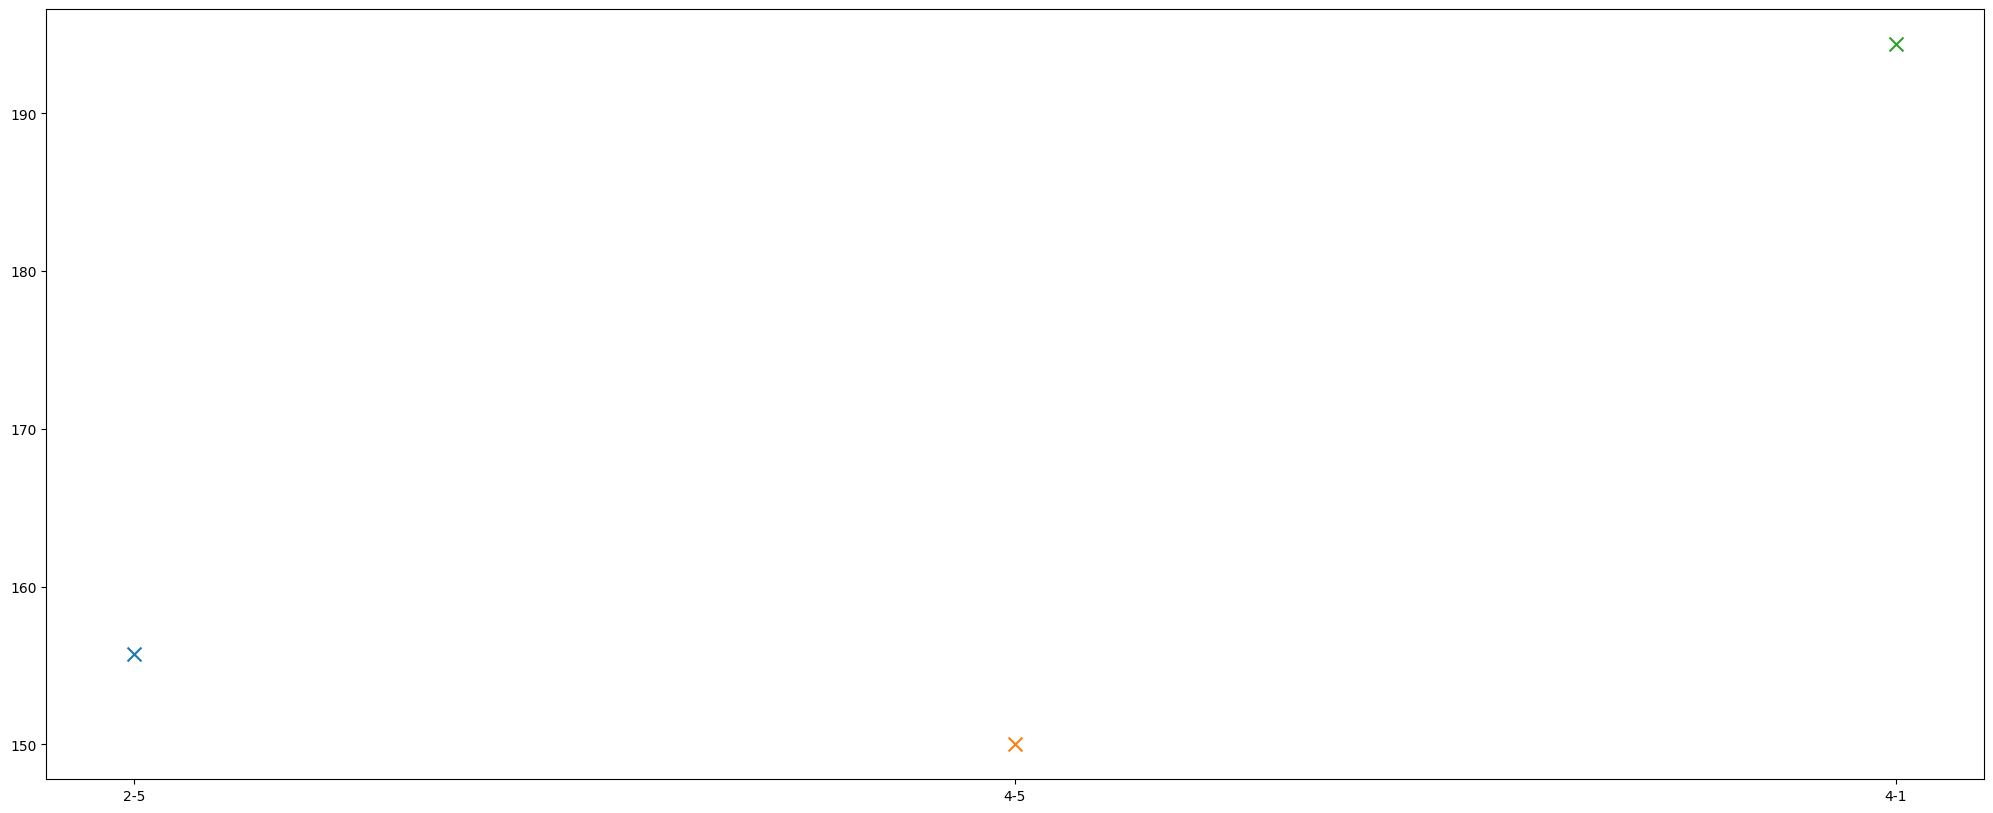

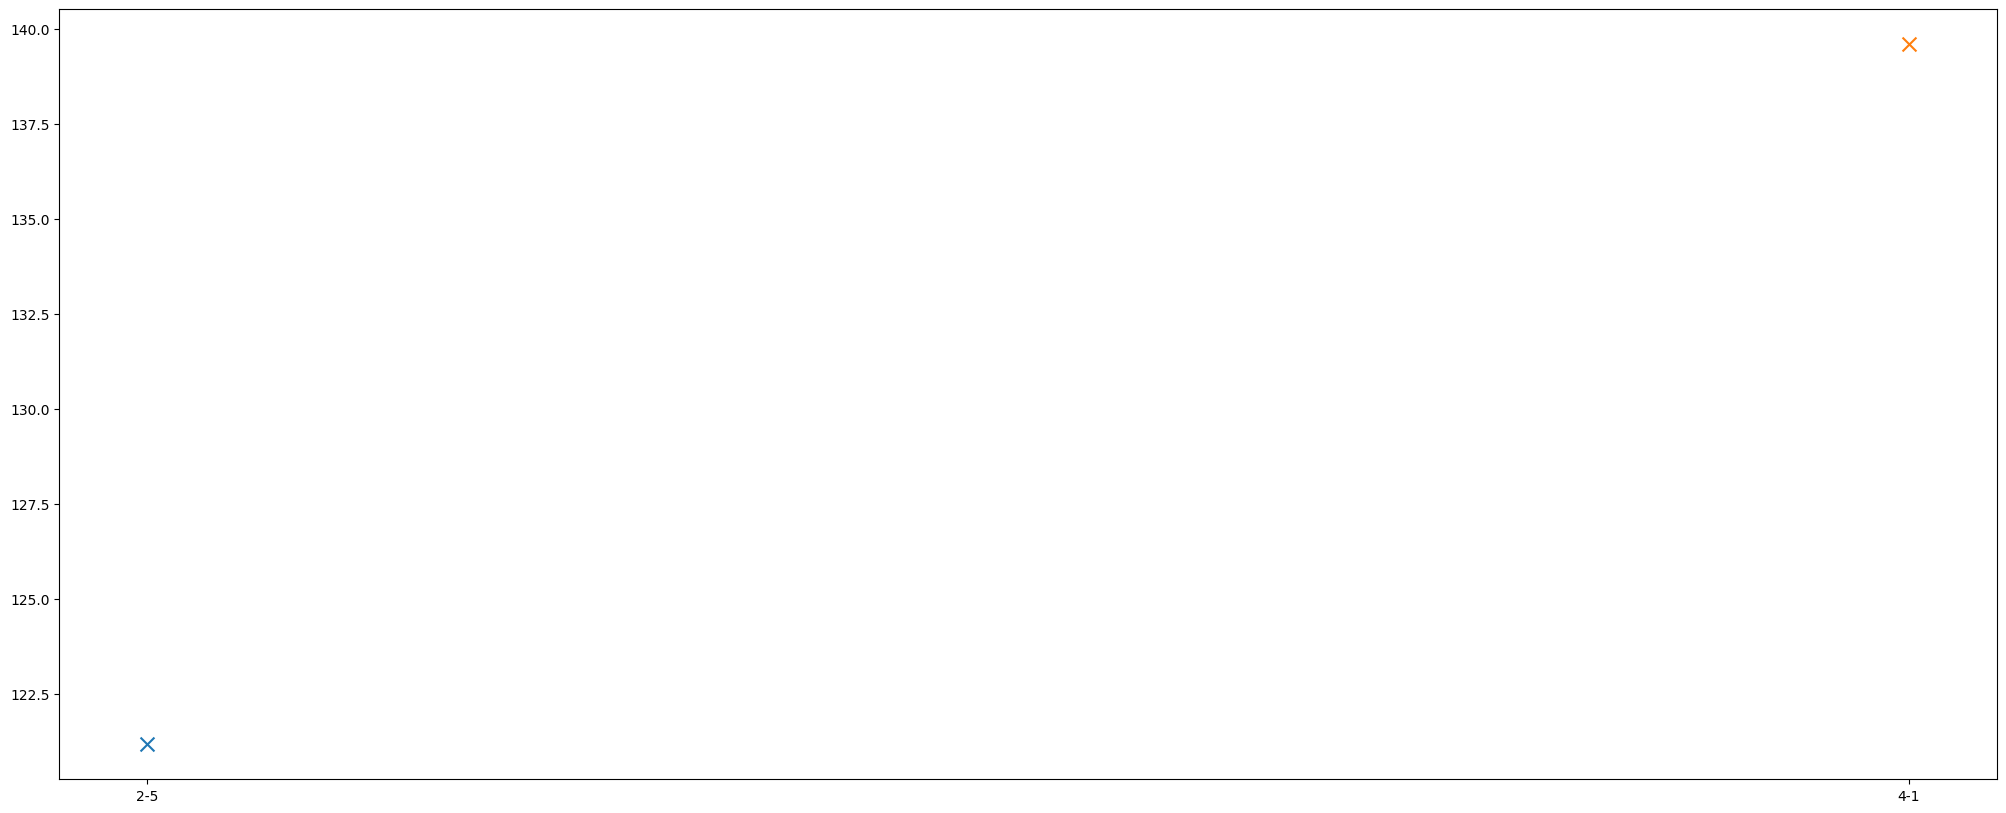

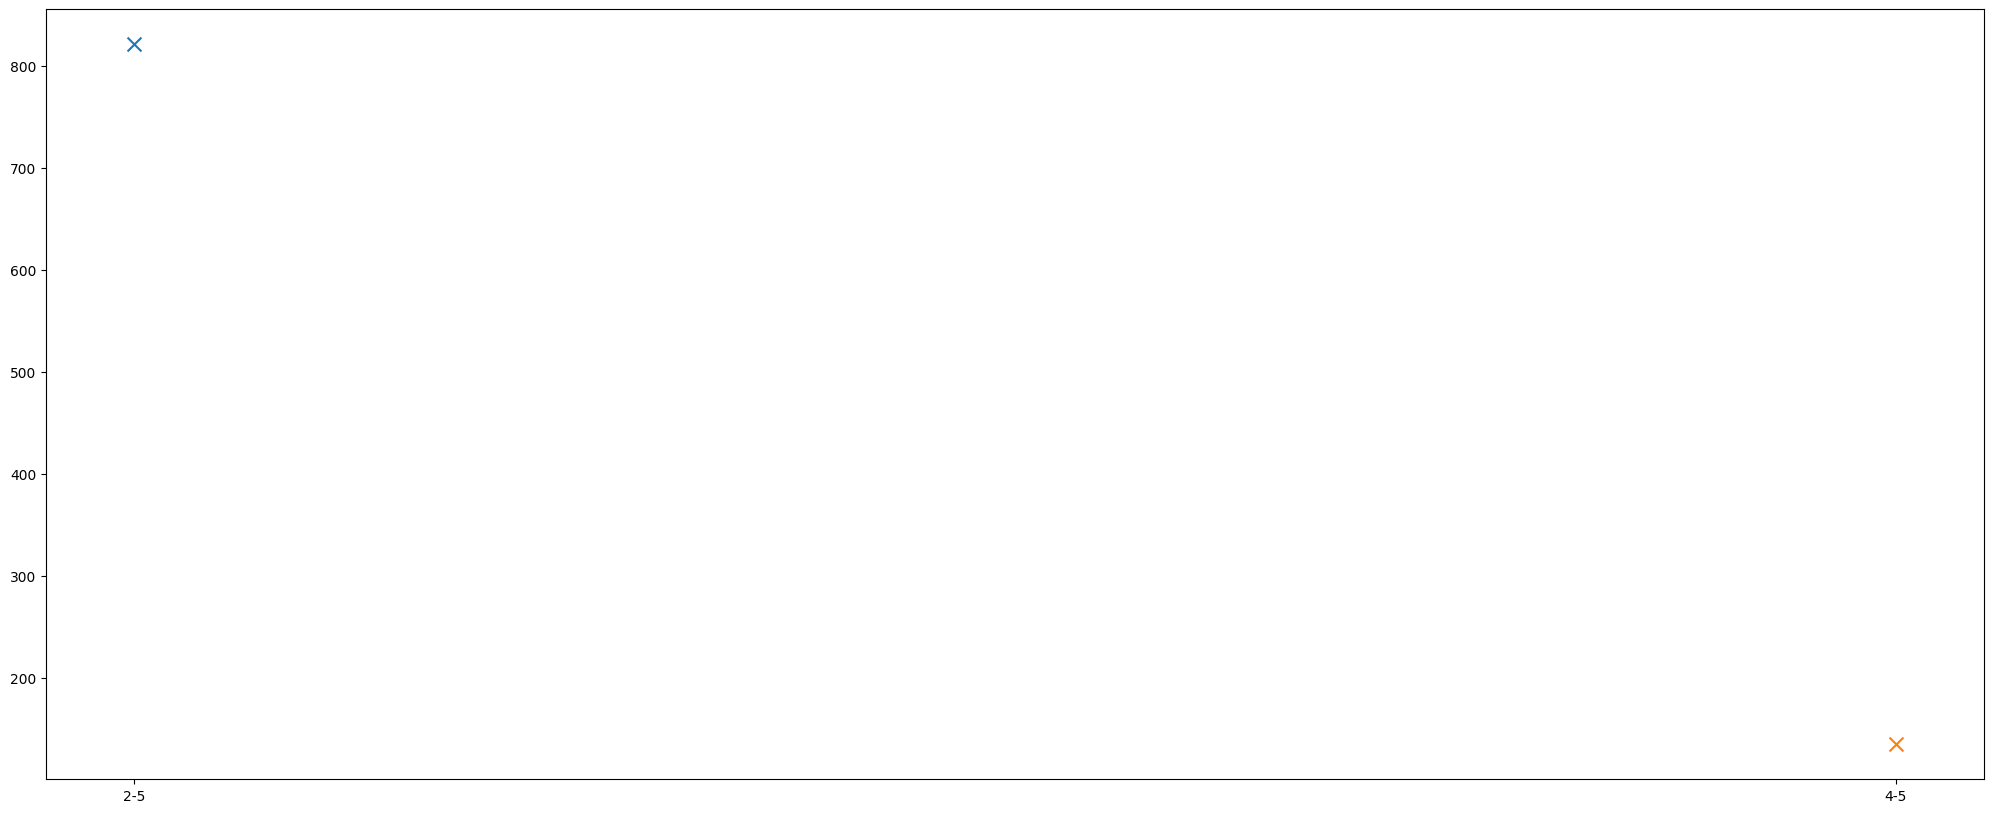

In [87]:
fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
# world_1_con_1_comp = [(per_bank_stats["bramble-2-5"][1][1][0]["total_times"][k]/30 -  per_bank_stats["bramble-2-5"][1][1][0]["warmup"][k]) for k in range(len(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"]))]
# world_1_con_3_comp = [(per_bank_stats["bramble-4-5"][1][3][0]["total_times"][k]/30 -  per_bank_stats["bramble-4-5"][1][3][0]["warmup"][k]) for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
# world_1_con_5_comp = [(per_bank_stats["bramble-4-1"][1][5][0]["total_times"][k]/30 -  per_bank_stats["bramble-4-1"][1][5][0]["warmup"][k]) for k in range(len(per_bank_stats["bramble-4-1"][1][5][0]["comp_times"]))]
den = 1#(iters+1)

world_1_con_1_comp = [(per_bank_stats["bramble-2-5"][1][1][0]["total_times"][k]/den) for k in range(len(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"]))]
world_1_con_3_comp = [(per_bank_stats["bramble-4-5"][1][3][0]["total_times"][k]/den) for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
world_1_con_5_comp = [(per_bank_stats["bramble-4-1"][1][5][0]["total_times"][k]/den) for k in range(len(per_bank_stats["bramble-4-1"][1][5][0]["comp_times"]))]

world_1_con_1_comp = [i for i in world_1_con_1_comp if i>0]
world_1_con_3_comp = [i for i in world_1_con_3_comp if i>0]
world_1_con_5_comp = [i for i in world_1_con_5_comp if i>0]
# axs.scatter(["2-5"]*len(world_1_con_1_comp), world_1_con_1_comp, s=100)
# axs.scatter(["4-5"]*len(world_1_con_3_comp), world_1_con_3_comp, s=100)
# axs.scatter(["4-1"]*len(world_1_con_5_comp), world_1_con_5_comp, s=100)

# axs.scatter("2-5", np.median(world_1_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_1_con_3_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_1_con_5_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_1_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.min(world_1_con_3_comp), marker="x", s=100)
axs.scatter("4-1", np.min(world_1_con_5_comp), marker="x", s=100)

fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][2][1][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]

world_2_con_1_comp = [(per_bank_stats["bramble-2-5"][2][1][1]["total_times"][k]/den - spec_warmup[k] ) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["comp_times"]))]
# world_1_con_3_comp = [per_bank_stats["bramble-4-5"][1][3][0]["comp_times"][k] -  per_bank_stats["bramble-4-5"][1][3][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-1"][2][5][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]

world_2_con_5_comp = [(per_bank_stats["bramble-4-1"][2][5][1]["total_times"][k]/den -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]

world_2_con_1_comp = [i for i in world_2_con_1_comp if i >0]
world_2_con_5_comp = [i for i in world_2_con_5_comp if i >0]

# axs.scatter(["2-5"]*len(world_2_con_1_comp), world_2_con_1_comp, s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_2_con_5_comp, s=100)

# axs.scatter("2-5", np.median(world_2_con_1_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_2_con_5_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_2_con_1_comp), marker="x", s=100)
axs.scatter("4-1", np.min(world_2_con_5_comp), marker="x", s=100)


fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][3][1][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]

world_3_con_1_comp = [(per_bank_stats["bramble-2-5"][3][1][2]["total_times"][k]/den -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-5"][3][3][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]

world_3_con_3_comp = [(per_bank_stats["bramble-4-5"][3][3][2]["total_times"][k]/den -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["comp_times"]))]
# world_2_con_5_comp = [per_bank_stats["bramble-4-1"][2][5][0]["comp_times"][k] -  per_bank_stats["bramble-4-1"][2][5][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]
world_3_con_1_comp = [i for i in world_3_con_1_comp if i > 0]
world_3_con_3_comp = [i for i in world_3_con_3_comp if i > 0]

# axs.scatter(["2-5"]*len(world_3_con_1_comp), world_3_con_1_comp, s=100)
# axs.scatter(["4-5"]*len(world_3_con_3_comp), world_3_con_3_comp, s=100)


# axs.scatter("2-5", np.median(world_3_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_3_con_3_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_3_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.min(world_3_con_3_comp), marker="x", s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_1_con_5_comp, s=100)

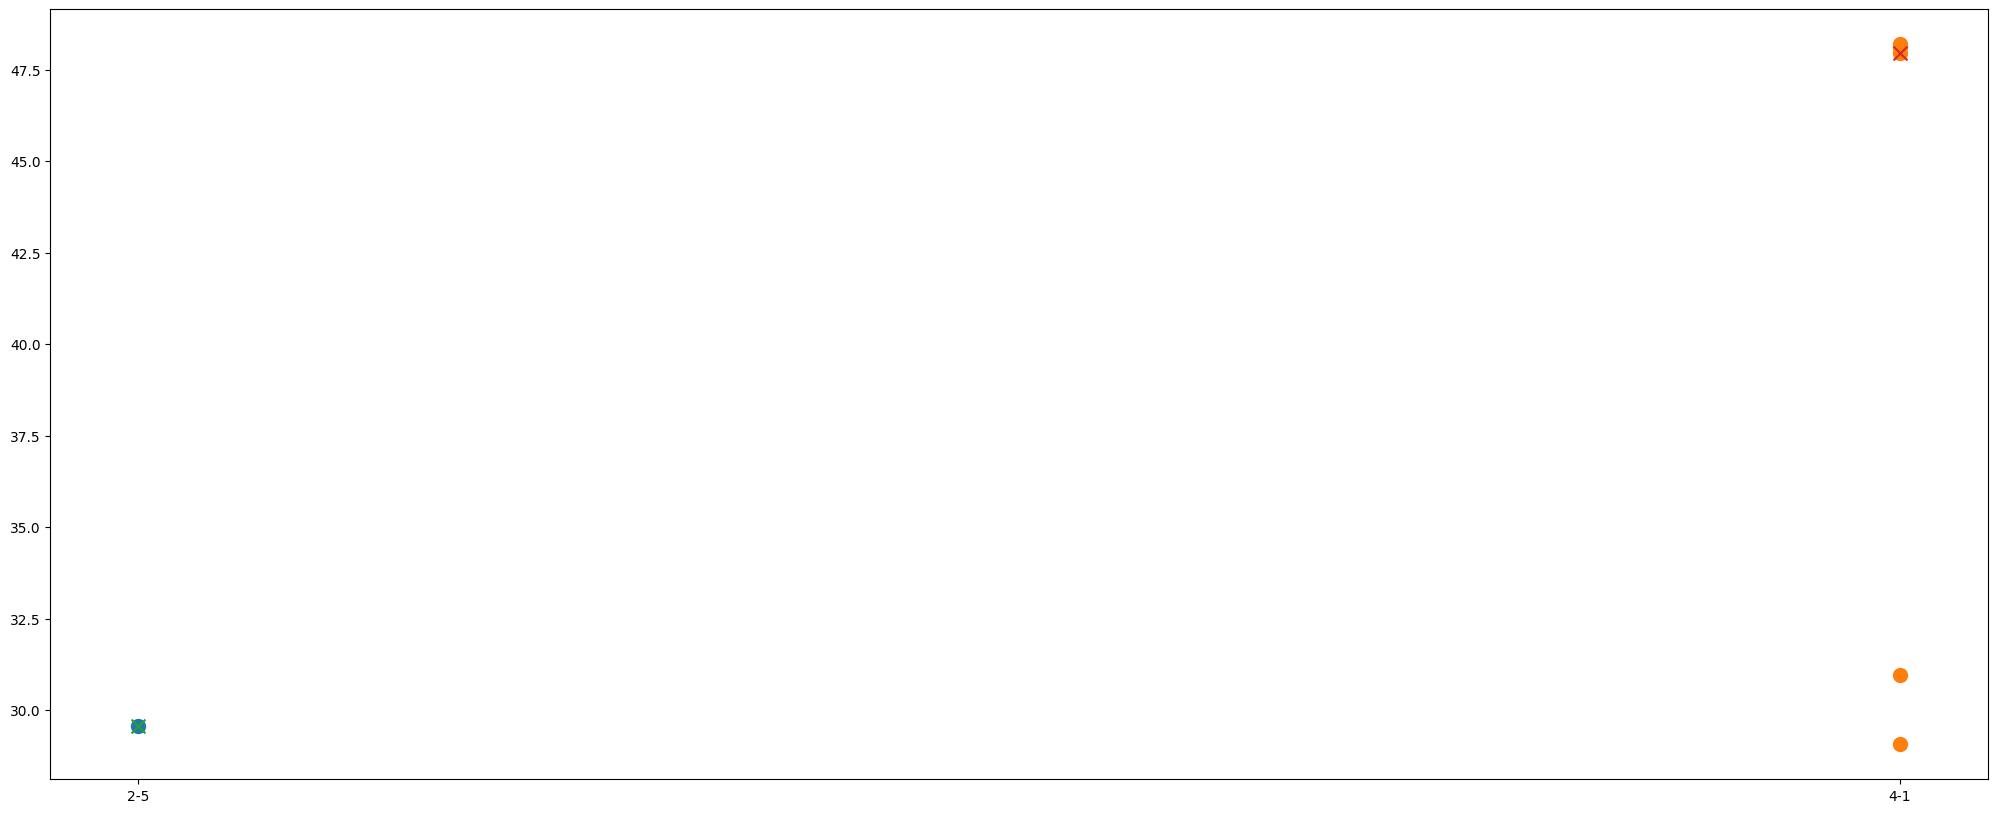

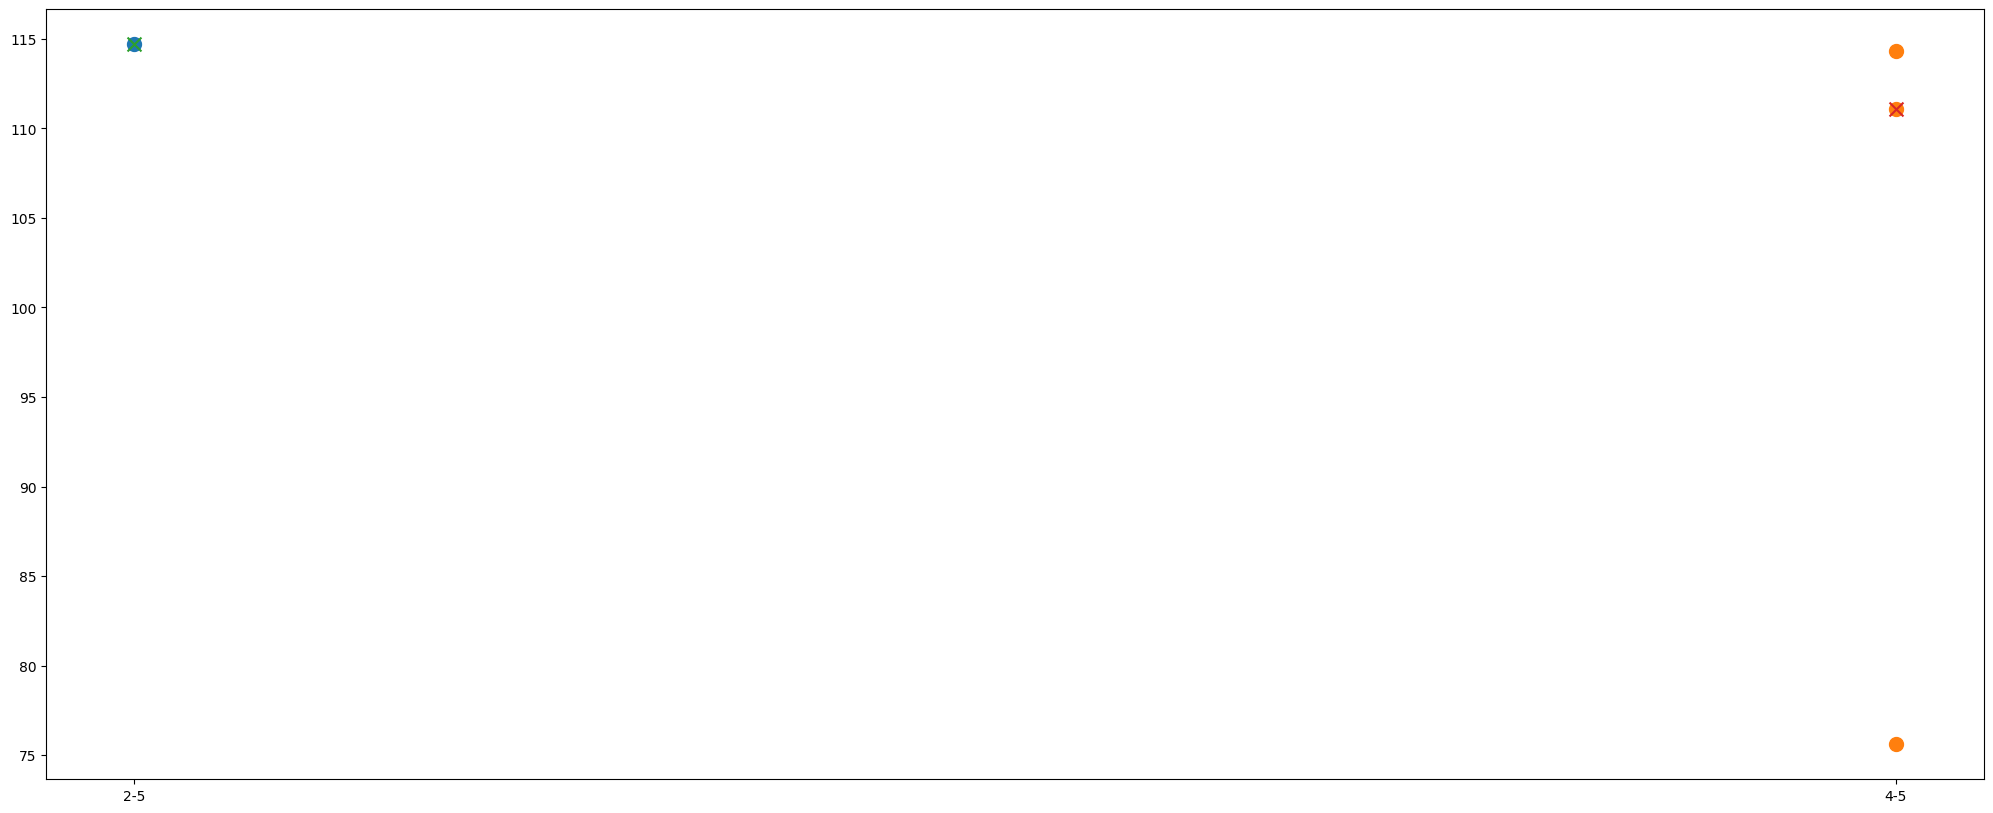

In [73]:
# fig, axs = plt.subplots(figsize=(25,10))
# # print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
# world_1_con_1_comp = [(per_bank_stats["bramble-2-5"][1][1][0]["net_times"][k])/30 for k in range(len(per_bank_stats["bramble-2-5"][1][1][0]["net_times"]))]
# world_1_con_3_comp = [(per_bank_stats["bramble-4-5"][1][3][0]["net_times"][k])/30 for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["net_times"]))]
# world_1_con_5_comp = [(per_bank_stats["bramble-4-1"][1][5][0]["net_times"][k])/30 for k in range(len(per_bank_stats["bramble-4-1"][1][5][0]["net_times"]))]

# # axs.scatter(["2-5"]*len(world_1_con_1_comp), world_1_con_1_comp, s=100)
# # axs.scatter(["4-5"]*len(world_1_con_3_comp), world_1_con_3_comp, s=100)
# # axs.scatter(["4-1"]*len(world_1_con_5_comp), world_1_con_5_comp, s=100)


# axs.scatter("2-5", np.median(world_1_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_1_con_3_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_1_con_5_comp), marker="x", s=100)

fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][2][1][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_2_con_1_comp = [(per_bank_stats["bramble-2-5"][2][1][1]["net_times"][k] - spec_warmup[k] ) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["net_times"]))]
# world_1_con_3_comp = [per_bank_stats["bramble-4-5"][1][3][0]["comp_times"][k] -  per_bank_stats["bramble-4-5"][1][3][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-1"][2][5][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_2_con_5_comp = [(per_bank_stats["bramble-4-1"][2][5][1]["net_times"][k] -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["net_times"]))]

axs.scatter(["2-5"]*len(world_2_con_1_comp), world_2_con_1_comp, s=100)
axs.scatter(["4-1"]*len(world_2_con_5_comp), world_2_con_5_comp, s=100)
axs.scatter("2-5", np.median(world_2_con_1_comp), marker="x", s=100)
axs.scatter("4-1", np.median(world_2_con_5_comp), marker="x", s=100)



fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][3][1][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_3_con_1_comp = [(per_bank_stats["bramble-2-5"][3][1][2]["net_times"][k] -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["net_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-5"][3][3][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_3_con_3_comp = [(per_bank_stats["bramble-4-5"][3][3][2]["net_times"][k] -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["net_times"]))]
# world_2_con_5_comp = [per_bank_stats["bramble-4-1"][2][5][0]["comp_times"][k] -  per_bank_stats["bramble-4-1"][2][5][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]
world_3_con_3_comp = [ i for i in world_3_con_3_comp if i > 0]
axs.scatter(["2-5"]*len(world_3_con_1_comp), world_3_con_1_comp, s=100)
axs.scatter(["4-5"]*len(world_3_con_3_comp), world_3_con_3_comp, s=100)


axs.scatter("2-5", np.median(world_3_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.median(world_3_con_3_comp), marker="x", s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_1_con_5_comp, s=100)

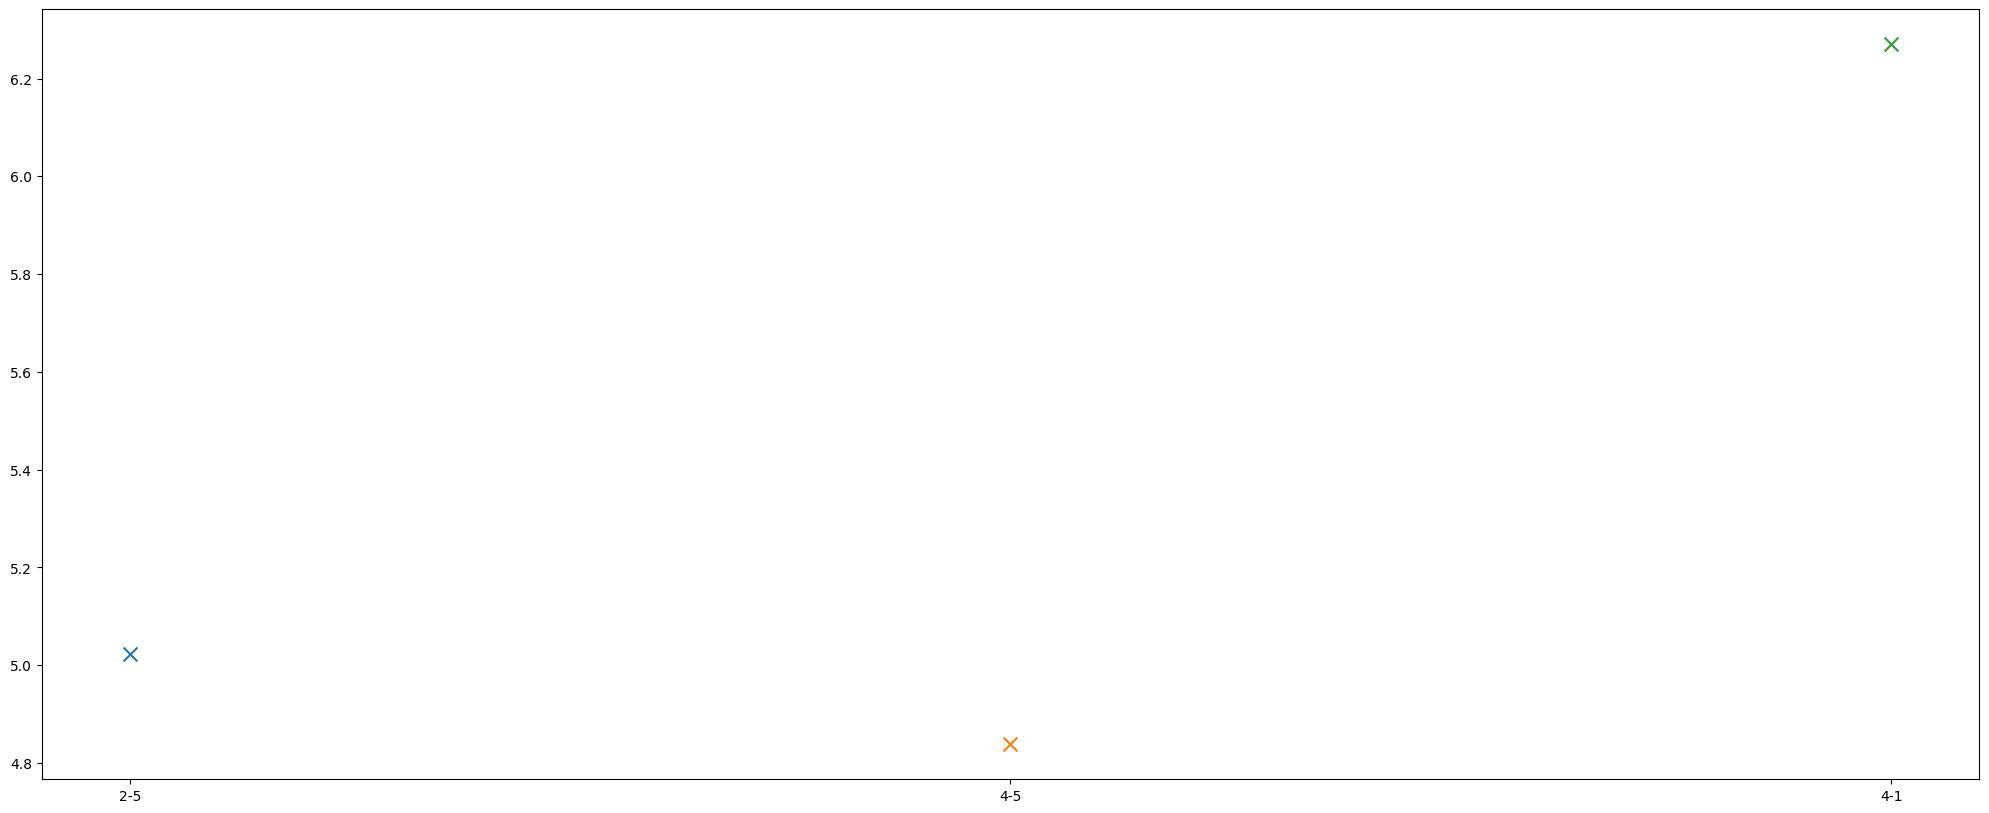

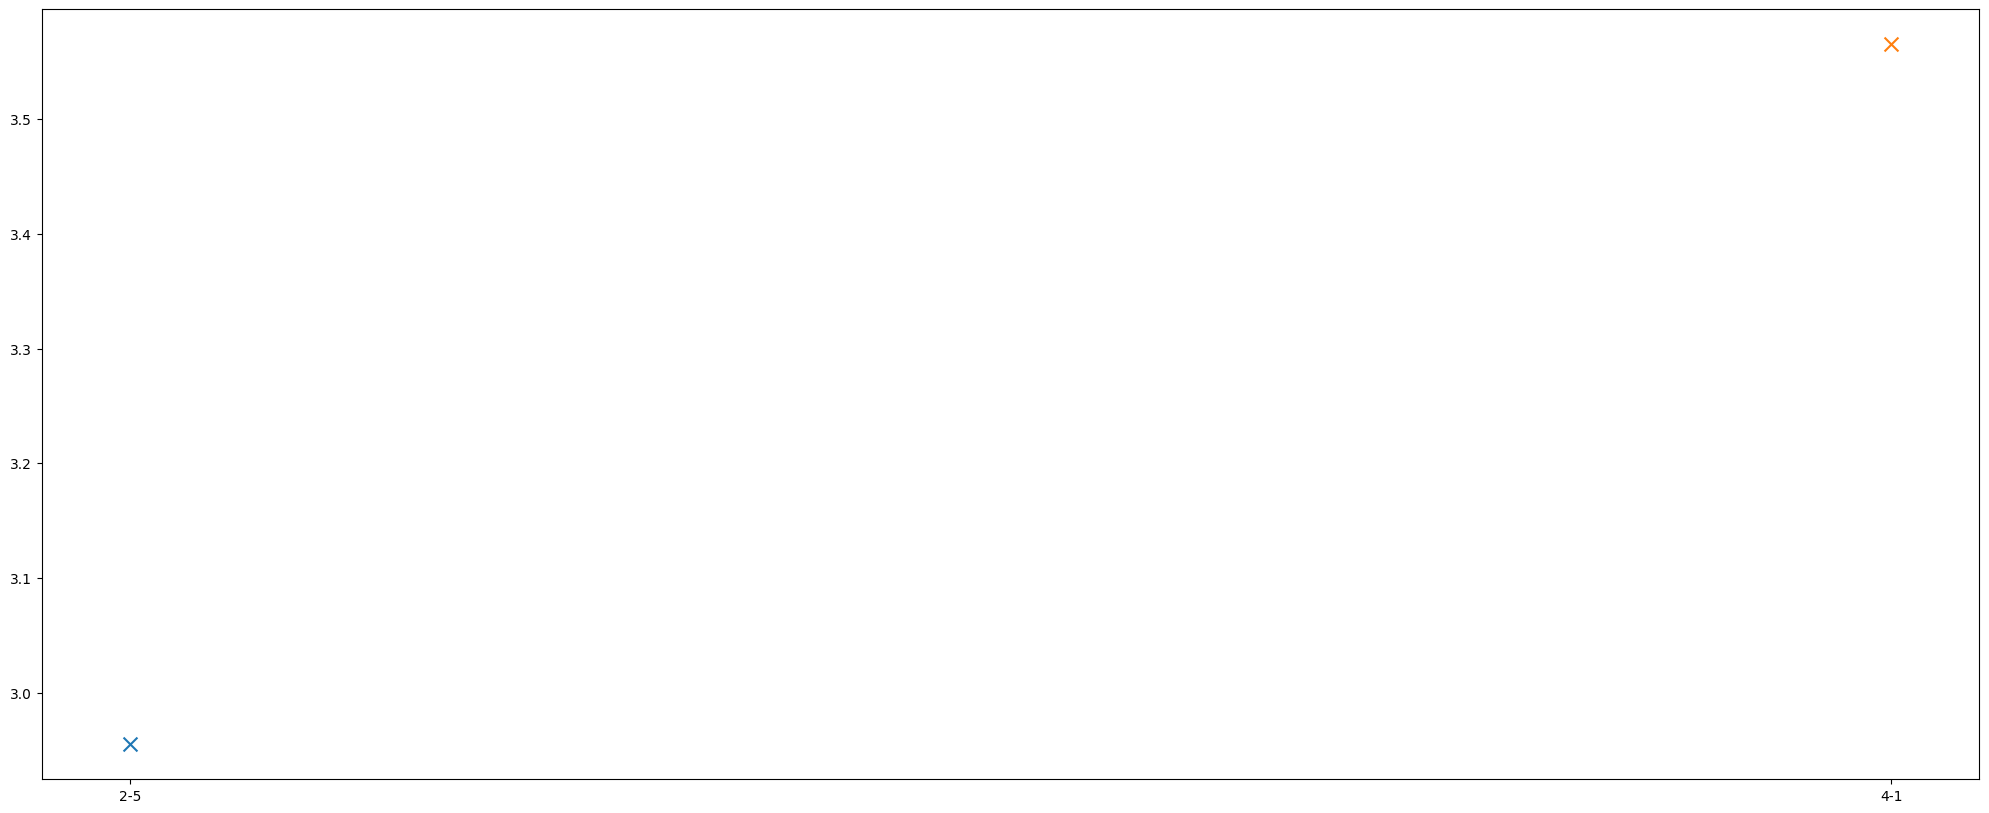

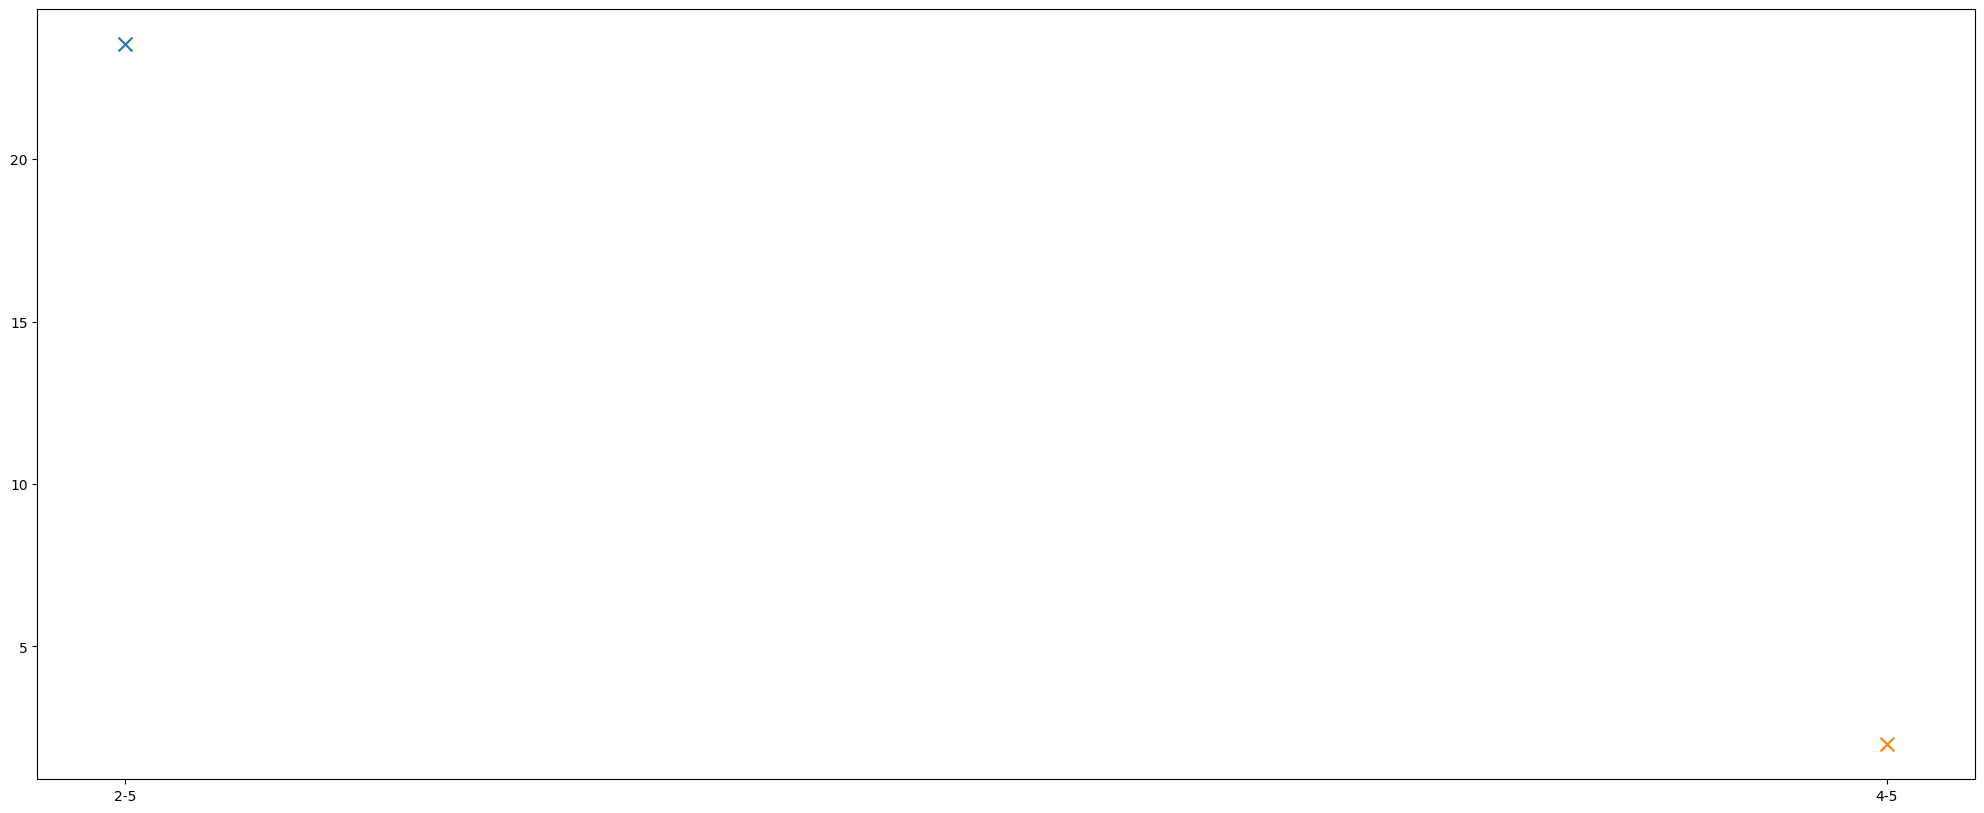

In [85]:
fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
world_1_con_1_comp = [(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"][k])/den for k in range(len(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"]))]
world_1_con_3_comp = [(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"][k])/den for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
world_1_con_5_comp = [(per_bank_stats["bramble-4-1"][1][5][0]["comp_times"][k])/den for k in range(len(per_bank_stats["bramble-4-1"][1][5][0]["comp_times"]))]

# axs.scatter(["2-5"]*len(world_1_con_1_comp), world_1_con_1_comp, s=100)
# axs.scatter(["4-5"]*len(world_1_con_3_comp), world_1_con_3_comp, s=100)
# axs.scatter(["4-1"]*len(world_1_con_5_comp), world_1_con_5_comp, s=100)


# axs.scatter("2-5", np.median(world_1_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_1_con_3_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_1_con_5_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_1_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.min(world_1_con_3_comp), marker="x", s=100)
axs.scatter("4-1", np.min(world_1_con_5_comp), marker="x", s=100)

fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][2][1][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_2_con_1_comp = [(per_bank_stats["bramble-2-5"][2][1][1]["comp_times"][k]/den - spec_warmup[k] ) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["comp_times"]))]
# world_1_con_3_comp = [per_bank_stats["bramble-4-5"][1][3][0]["comp_times"][k] -  per_bank_stats["bramble-4-5"][1][3][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-1"][2][5][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_2_con_5_comp = [(per_bank_stats["bramble-4-1"][2][5][1]["comp_times"][k]/den -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]

# axs.scatter(["2-5"]*len(world_2_con_1_comp), world_2_con_1_comp, s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_2_con_5_comp, s=100)
# axs.scatter("2-5", np.median(world_2_con_1_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_2_con_5_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_2_con_1_comp), marker="x", s=100)
axs.scatter("4-1", np.min(world_2_con_5_comp), marker="x", s=100)


fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][3][1][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_3_con_1_comp = [(per_bank_stats["bramble-2-5"][3][1][2]["comp_times"][k]/30 -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-5"][3][3][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_3_con_3_comp = [(per_bank_stats["bramble-4-5"][3][3][2]["comp_times"][k]/30 -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["comp_times"]))]
# world_2_con_5_comp = [per_bank_stats["bramble-4-1"][2][5][0]["comp_times"][k] -  per_bank_stats["bramble-4-1"][2][5][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]
world_3_con_3_comp = [ i for i in world_3_con_3_comp if i > 0]
# axs.scatter(["2-5"]*len(world_3_con_1_comp), world_3_con_1_comp, s=100)
# axs.scatter(["4-5"]*len(world_3_con_3_comp), world_3_con_3_comp, s=100)


# axs.scatter("2-5", np.median(world_3_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_3_con_3_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_3_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.min(world_3_con_3_comp), marker="x", s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_1_con_5_comp, s=100)